In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

In [2]:
DOMINANCE_FACTOR = 2.0
MAX_DEPTH_m = 3000.0
MIN_TILT_km = 5.0
ALIGNMENT_DEG = 45.0
RANDOM_TOLERANCE_FRACTION = ALIGNMENT_DEG / 180.0
SHELF_LON = 154.75

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_region_labels(df_eddies, grid)
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)

config = PVAlignmentConfig(
    dominance_factor=DOMINANCE_FACTOR, max_topo_depth_m=MAX_DEPTH_m,
    min_tilt_distance_km=MIN_TILT_km,
)
d = add_pv_alignment_diagnostics(df_eddies, config)
assert d.beta.dropna().median() > 0, 'Expected positive planetary beta after gradient sign correction.'
topographic = d[d.shallow_ocean_topographic & d.direction_valid].copy()
topographic = topographic[np.isfinite(topographic.PV_grad_mag) & (topographic.PV_grad_mag > 0)]
topographic['log_PV_grad_mag'] = np.log(topographic.PV_grad_mag)
topographic['raw_signed_PV_mismatch'] = topographic.dtheta_PV_grad
topographic['preference_error'] = np.where(topographic.Cyc.eq('AE'),
    topographic.raw_signed_PV_mismatch, 180.0-topographic.raw_signed_PV_mismatch)
topographic['within_tolerance'] = topographic.preference_error <= ALIGNMENT_DEG
topographic['response_cosine'] = np.cos(np.deg2rad(topographic.raw_signed_PV_mismatch))
topographic['shelf_class'] = np.where(topographic.lon < SHELF_LON, 'On-shelf', 'Off-shelf')


In [5]:
full = df_eddies.groupby('Eddy').size()
kept = topographic.groupby('Eddy').size()

complete_eddies = full.index[(full - kept.reindex(full.index, fill_value=0)).eq(6)]
# complete_eddies = full.index[(full - kept.reindex(full.index, fill_value=0)) < 10]
df_eddies[df_eddies.Eddy.isin(complete_eddies)].groupby('Cyc').Eddy.nunique()

Cyc
AE    56
CE    92
Name: Eddy, dtype: int64

(np.float64(0.0),
 np.float64(988.1356688684336),
 np.float64(0.0),
 np.float64(1561.702894718129))

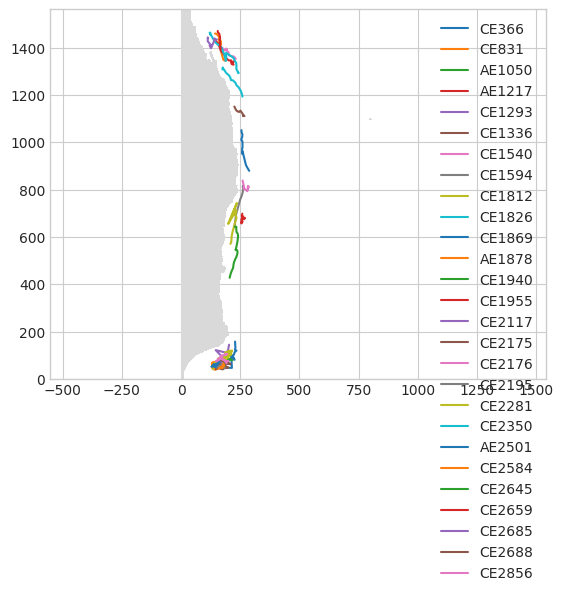

In [14]:
df_shelf = topographic[(topographic.Eddy.isin(complete_eddies))&(topographic.Age>0)&(topographic.shelf_class=='On-shelf')].copy()

plt.contourf(grid.X_grid, grid.Y_grid, np.where(grid.mask_rho, np.nan,0))
for eddy in df_shelf.Eddy.unique():
    df = df_shelf[df_shelf.Eddy==eddy].copy()
    plt.plot(df.xc, df.yc, label=f'{df.iloc[0].Cyc}{eddy}')
plt.legend()
plt.axis('equal')

In [38]:
def time_plot(eddy, df_data, grid=grid):
    df = df_data[df_data.Eddy.eq(eddy)].copy()
    t = df.Day - df.Day.iloc[0]

    fig = plt.figure(figsize=(12,10))
    gs = fig.add_gridspec(6, 2, width_ratios=[2,1])
    axs = [fig.add_subplot(gs[i,0]) for i in range(6)]
    south = df.TiltDir.between(90, 270)
    for ax in axs:
        for i in np.where(south)[0]:
            ax.axvspan(t.iloc[i]-.5, t.iloc[i]+.5, color='grey', alpha=.12, lw=0)
    axm = fig.add_subplot(gs[:,1])

    axs[0].plot(t, df.TiltDis)
    axs[0].set_ylabel('TiltDis')
    ax0 = axs[0].twinx()
    ax0.plot(t, df.PV_grad_mag, color='tab:red')
    ax0.set_ylabel('PV grad mag', color='tab:red')

    axs[1].plot(t, np.exp(df.topo_plan_ratio))
    axs[1].plot(t, np.exp(df.topo_plan_ratio_smooth))
    axs[1].set_ylabel('Topo/plan')

    axs[2].plot(t, df.Ro)
    axs[2].set_ylabel('Ro')
    ax2 = axs[2].twinx()
    ax2.plot(t, df.w, color='tab:red', label='w')
    # ax2.plot(t, df.f, color='tab:orange', label='f')
    ax2.set_ylabel('w')

    axs[3].plot(t, df.PV)
    axs[3].set_ylabel('PV')
    ax3 = axs[3].twinx()
    ax3.plot(t, df.h, color='tab:red')
    ax3.invert_yaxis()
    ax3.set_ylabel('h', color='tab:red')

    axs[4].plot(t, df.beta)
    axs[4].set_ylabel('beta')
    ax4 = axs[4].twinx()
    ax4.plot(t, df.w+df.f, color='tab:red')
    ax4.set_ylabel('abs_vort = w + f', #'Latitude', 
                   color='tab:red')

    axs[5].scatter(t, df.PV_grad_theta, s=10, label='PV grad')
    axs[5].scatter(t, df.TiltDir, s=10, label='Tilt')
    axs[5].plot(t, df.TiltDir)
    axs[5].scatter(t, df.dtheta_PV_grad, s=10, label=r'$\Delta\theta$')
    axs[5].axhspan(90, 270, color='grey', alpha=.15)
    axs[5].set(xlabel='Eddy age [days]', ylabel='Direction [°]')
    axs[5].legend()

    th = np.deg2rad(df.TiltDir)
    xb = df.xc - df.TiltDis*np.sin(th)
    yb = df.yc - df.TiltDis*np.cos(th)
    
    pad = 20
    xmin, xmax = min(df.xc.min(), xb.min())-pad, max(df.xc.max(), xb.max())+pad
    ymin, ymax = min(df.yc.min(), yb.min())-pad, max(df.yc.max(), yb.max())+pad
    
    ii = ((grid.X_grid >= xmin) & (grid.X_grid <= xmax) &
          (grid.Y_grid >= ymin) & (grid.Y_grid <= ymax))

    h = np.where((grid.mask_rho == 1) & ii, grid.h/1e3, np.nan)
    cf = axm.contourf(grid.X_grid, grid.Y_grid, h, cmap='Greys_r')
    fig.colorbar(cf, ax=axm, label='Depth (km)', shrink=.5)
    
    axm.set(xlim=(xmin,xmax), ylim=(ymin,ymax))

    cyc = df.iloc[0].Cyc
    clr = 'r' if cyc == 'AE' else 'b'
    axm.plot(df.xc, df.yc, '.-', color=clr, label='Surface')
    axm.scatter(xb, yb, s=10, color=clr, label='Bottom')
    for xs, ys, xbot, ybot, theta in zip(df.xc, df.yc, xb, yb, df.dtheta_PV_grad):
        clr = 'g' if theta<(180-45) else 'r'
        axm.plot([xs, xbot], [ys, ybot], color=clr, alpha=.25)

    axm.set(xlabel='x (km)', ylabel='y (km)')
    axm.set_aspect('equal')
    axm.legend()

    fig.suptitle(f'{cyc}{eddy}')
    plt.tight_layout()
    plt.show()

In [17]:
df_shelf.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R', 'Age', 'Date',
       'fname', 'TiltDis', 'TiltDir', 'Region', 'f', 'h', 'dhdx', 'dhdy',
       'beta', 'abs_vort', 'PV', 'PV_grad_plan_x', 'PV_grad_plan_y',
       'PV_grad_topo_x', 'PV_grad_topo_y', 'PV_grad_x', 'PV_grad_y',
       'PV_grad_plan_mag', 'PV_grad_plan_theta', 'PV_grad_topo_mag',
       'PV_grad_topo_theta', 'PV_grad_mag', 'PV_grad_theta', 'dtheta_PV_grad',
       'dtheta_PV_grad_topo', 'dtheta_PV_grad_plan', 'Ro', 'topo_plan_ratio',
       'topo_plan_ratio_smooth', 'planetary_strong', 'open_ocean_planetary',
       'topographic_strong', 'shallow_ocean_topographic',
       'signed_dtheta_PV_grad', 'expected_PV_theta',
       'expected_direction_error', 'direction_valid', 'expected_match',
       'log_PV_grad_mag', 'raw_signed_PV_mismatch', 'preference_error',
       'within_tolerance', 'response_cosine', 'shelf_class'],
      dtype='object

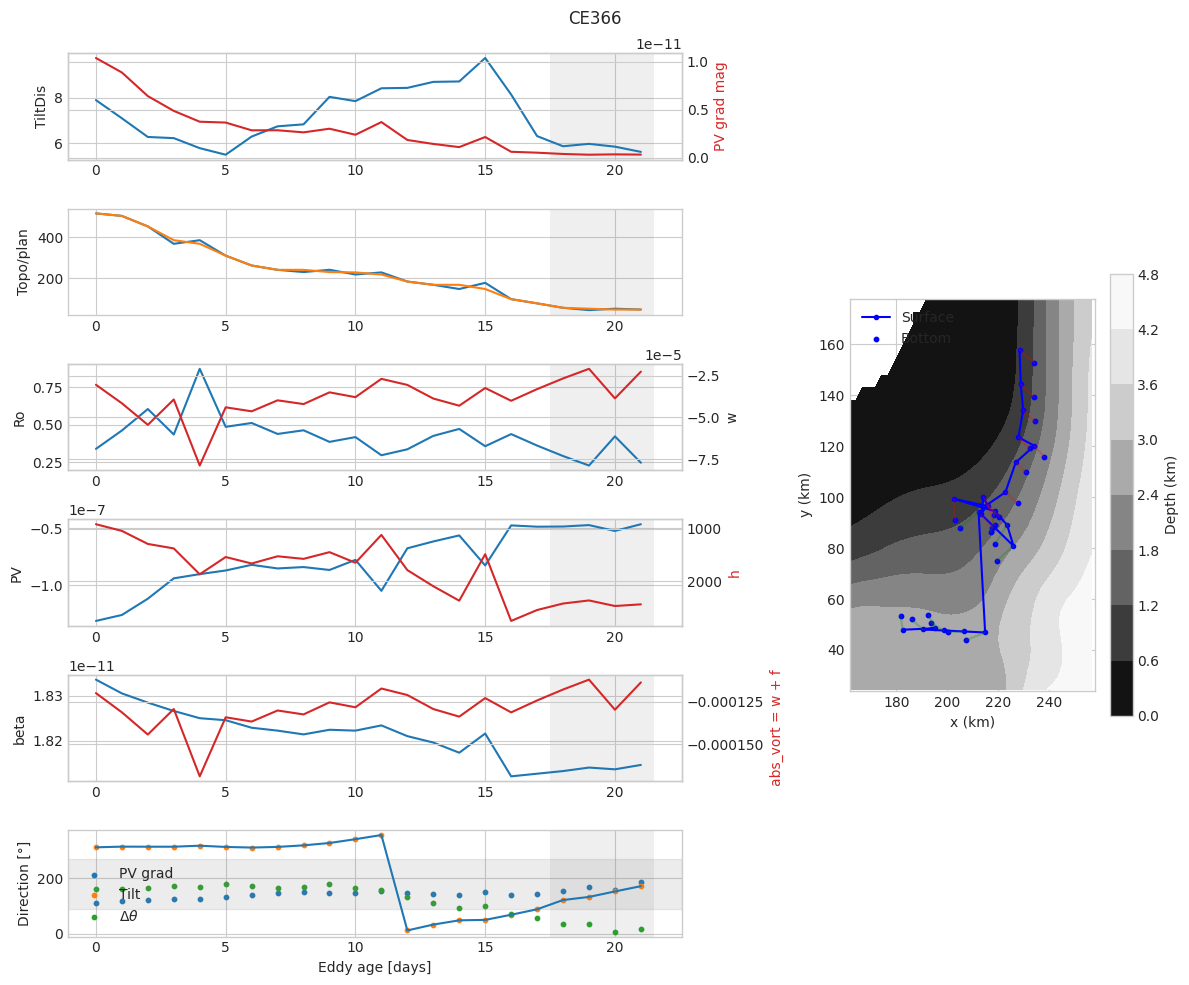

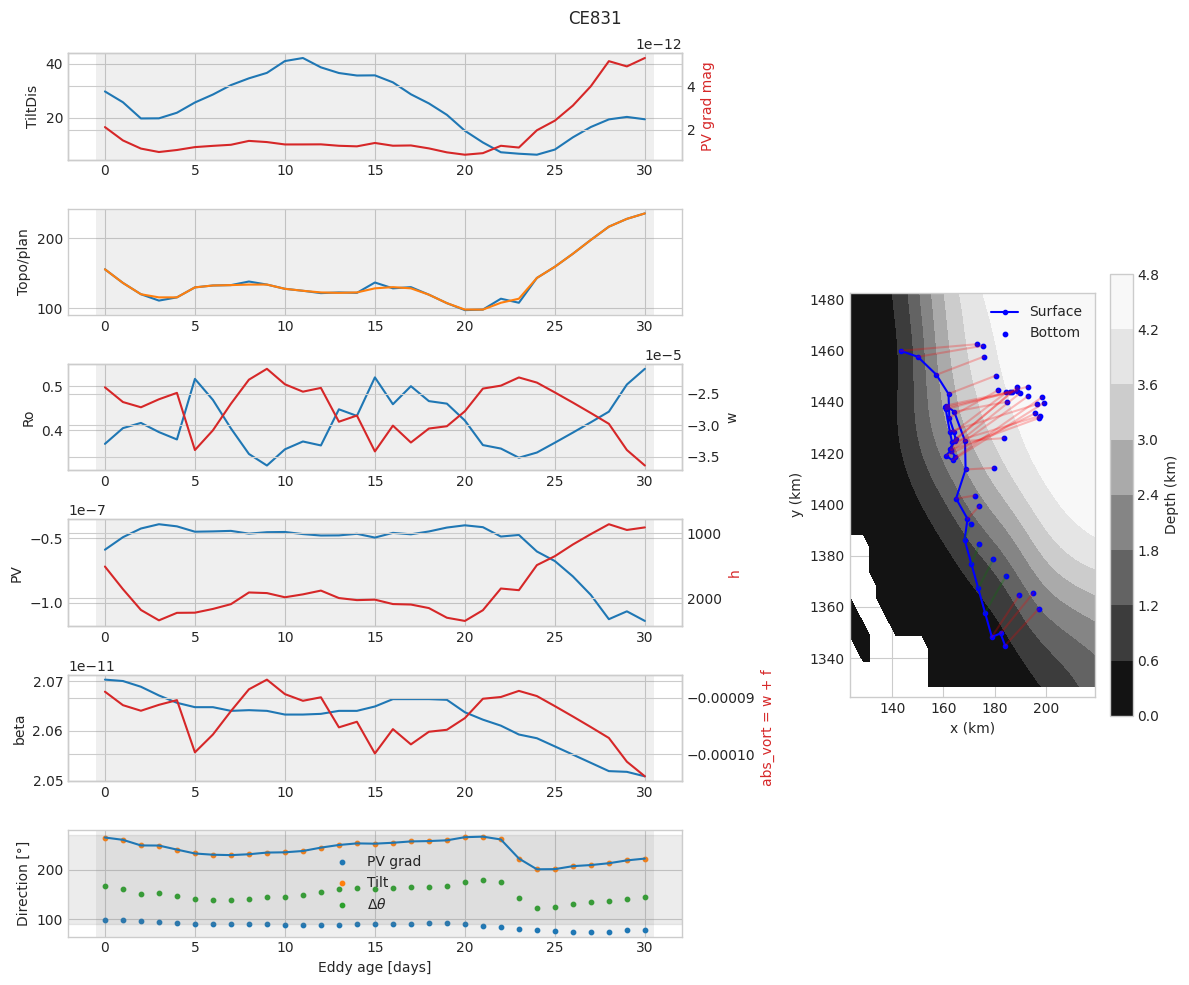

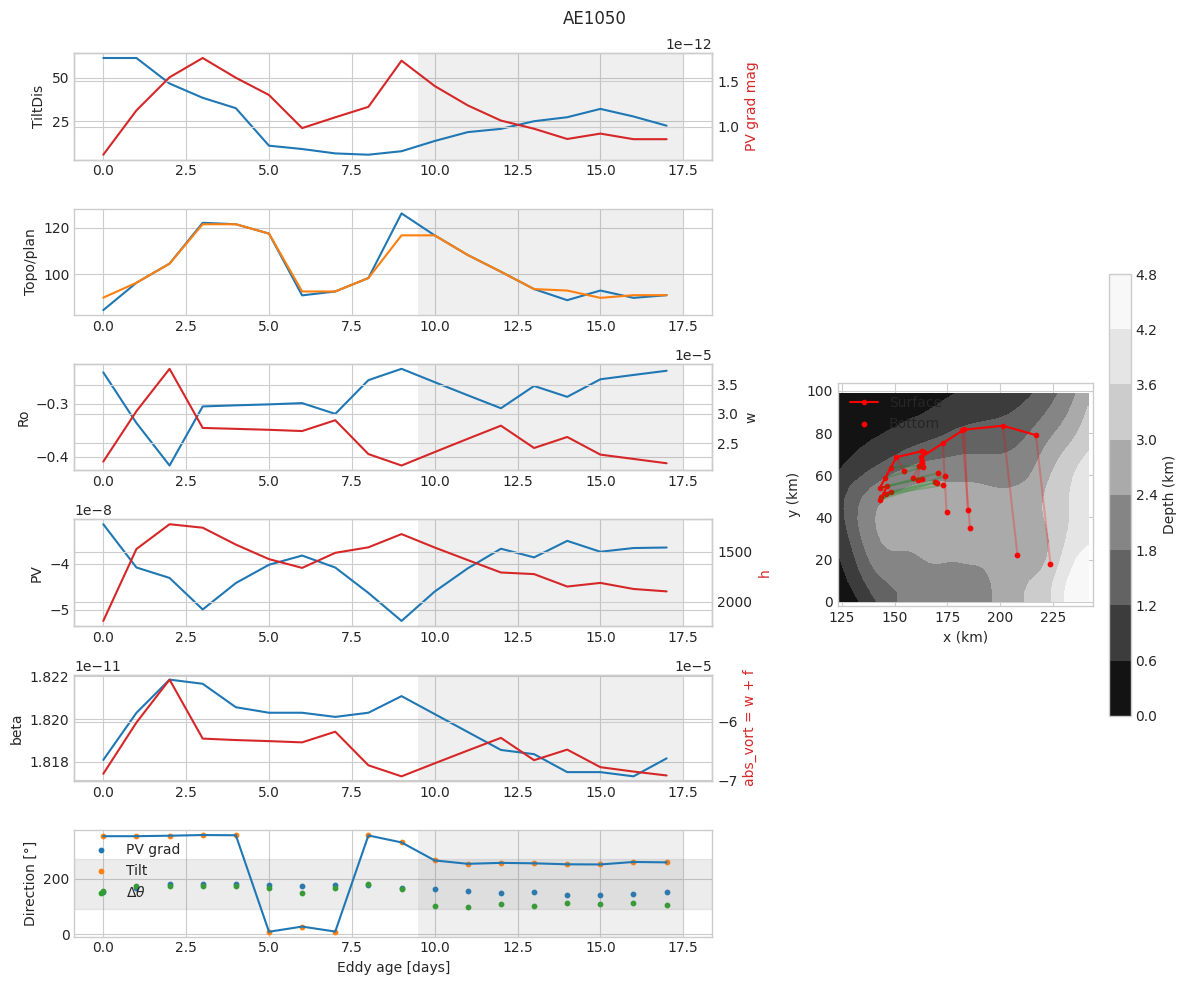

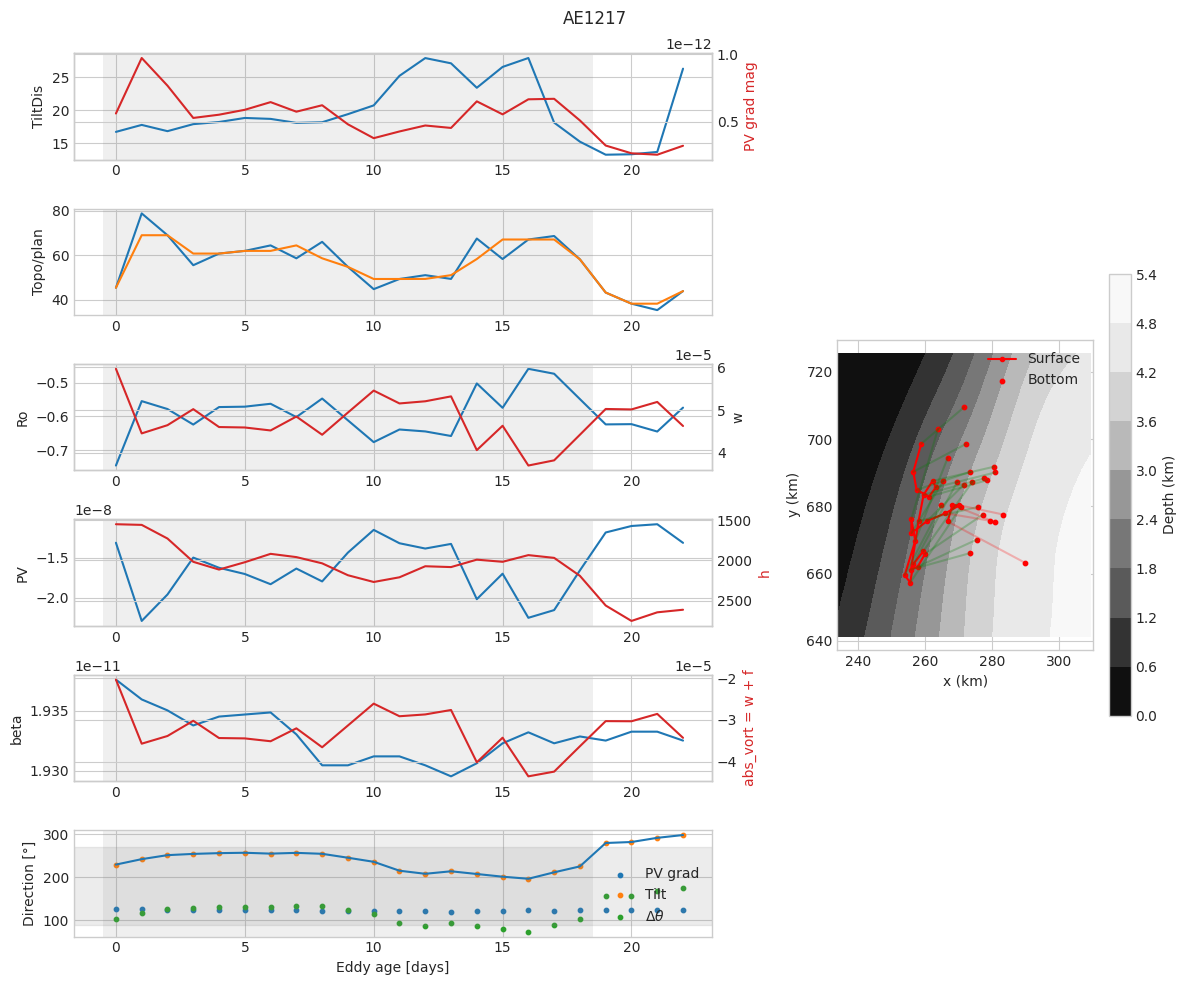

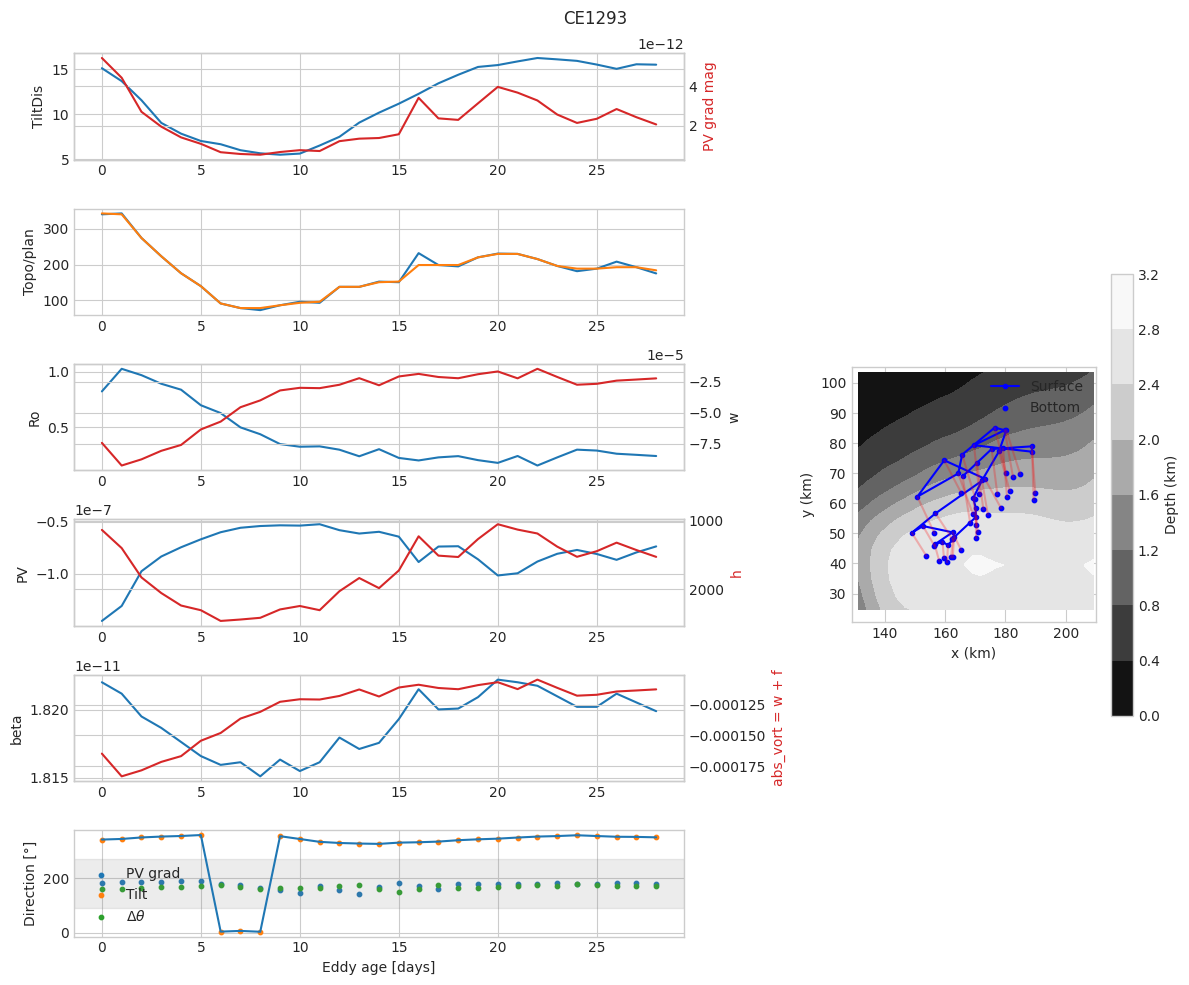

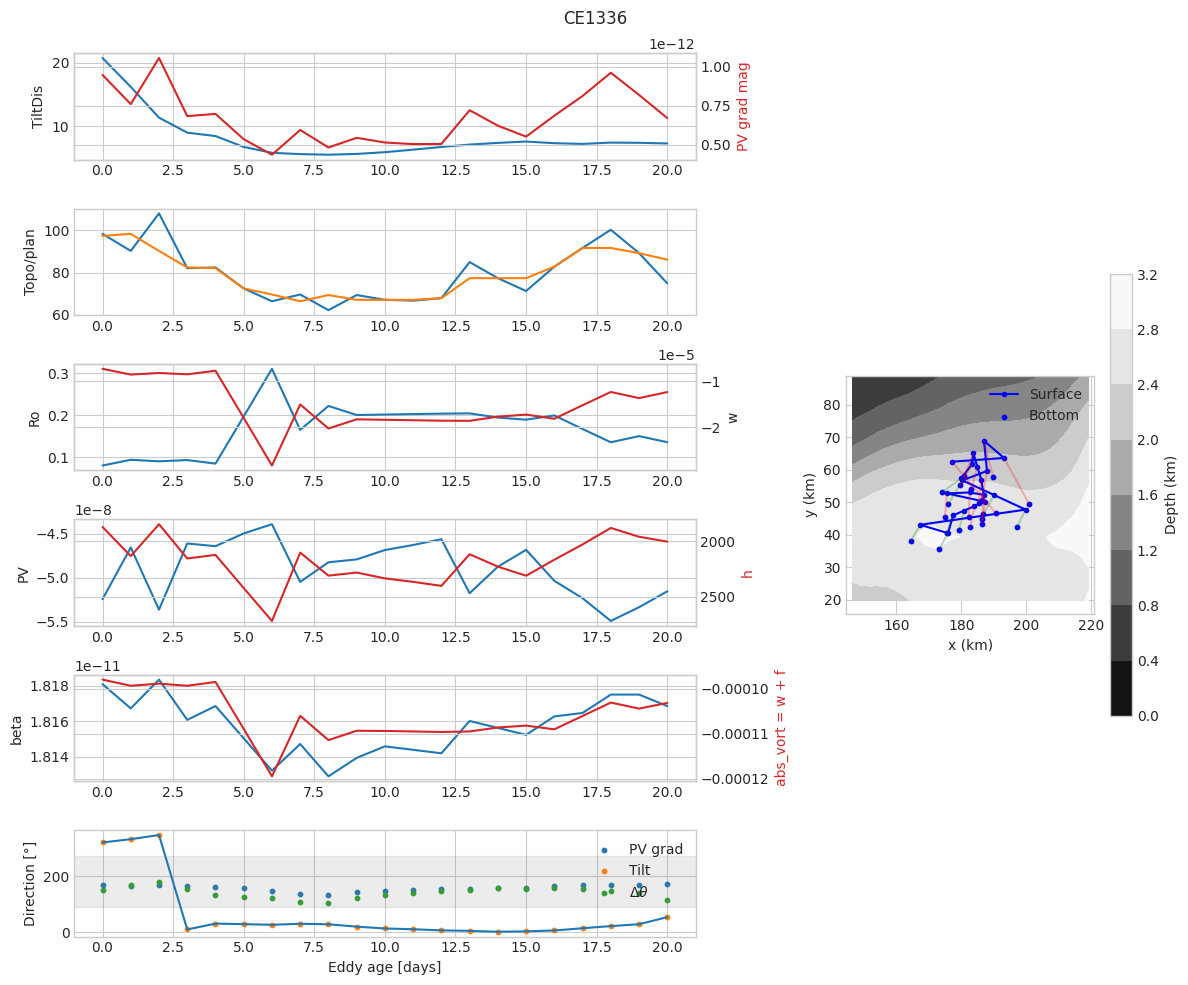

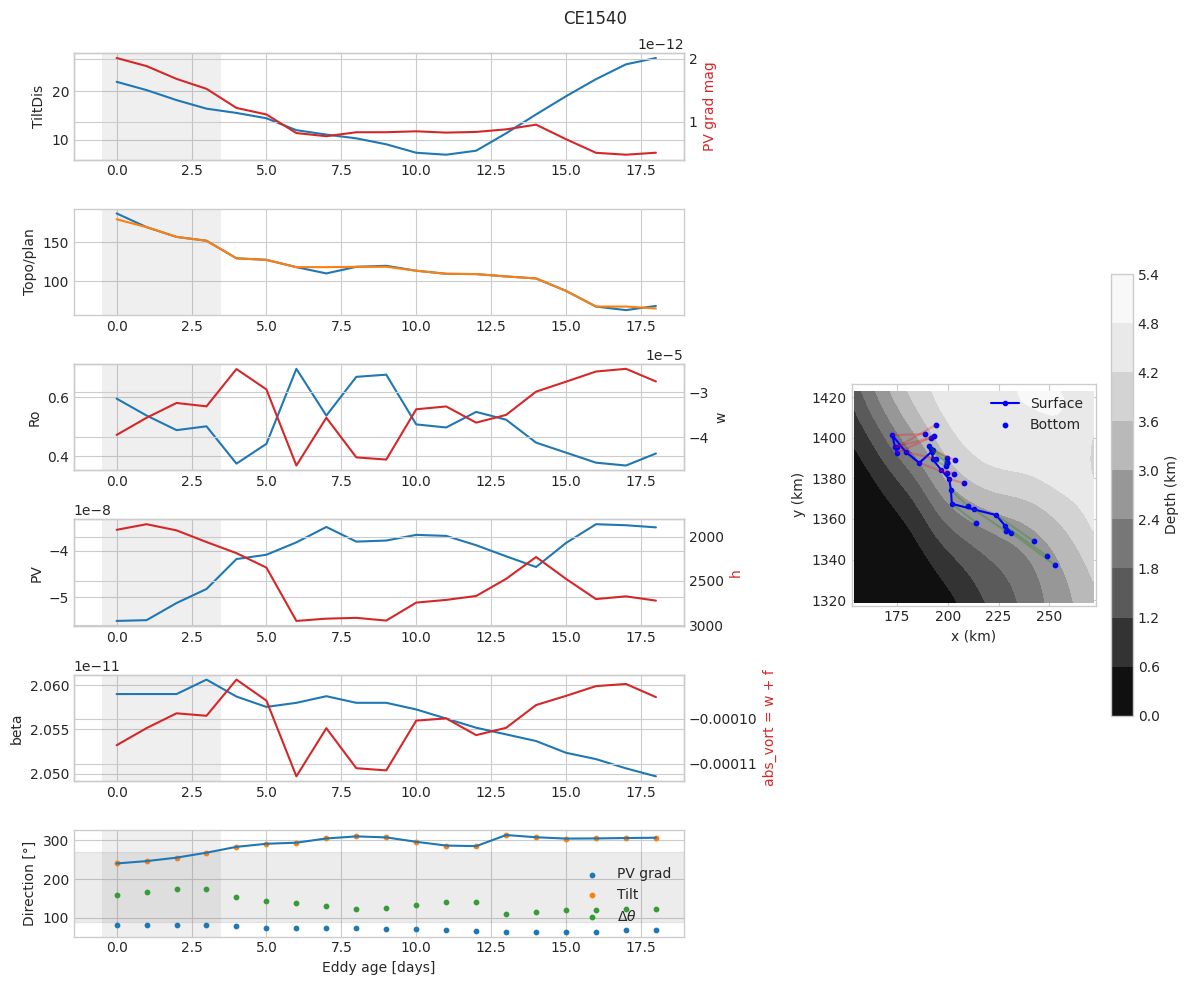

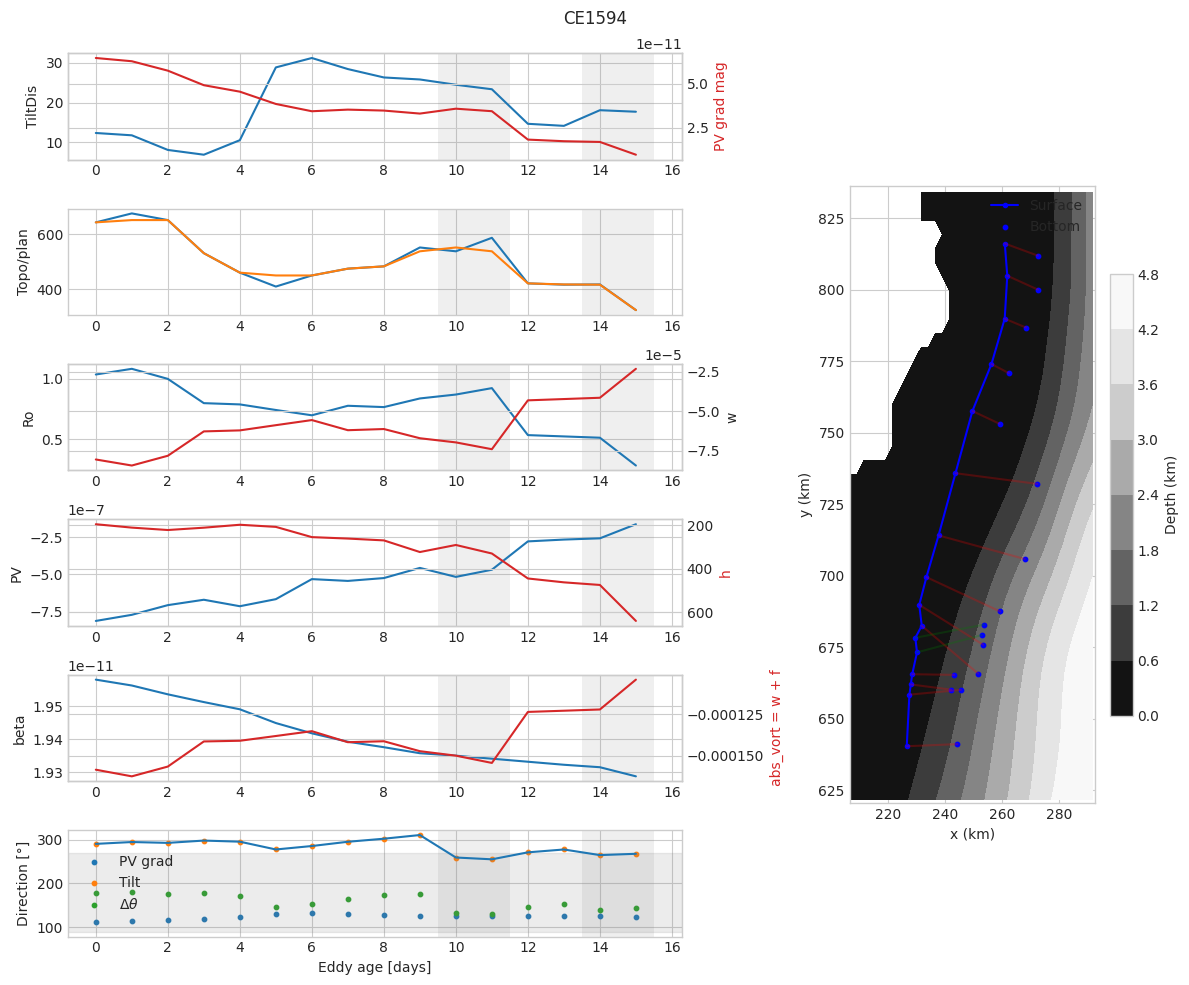

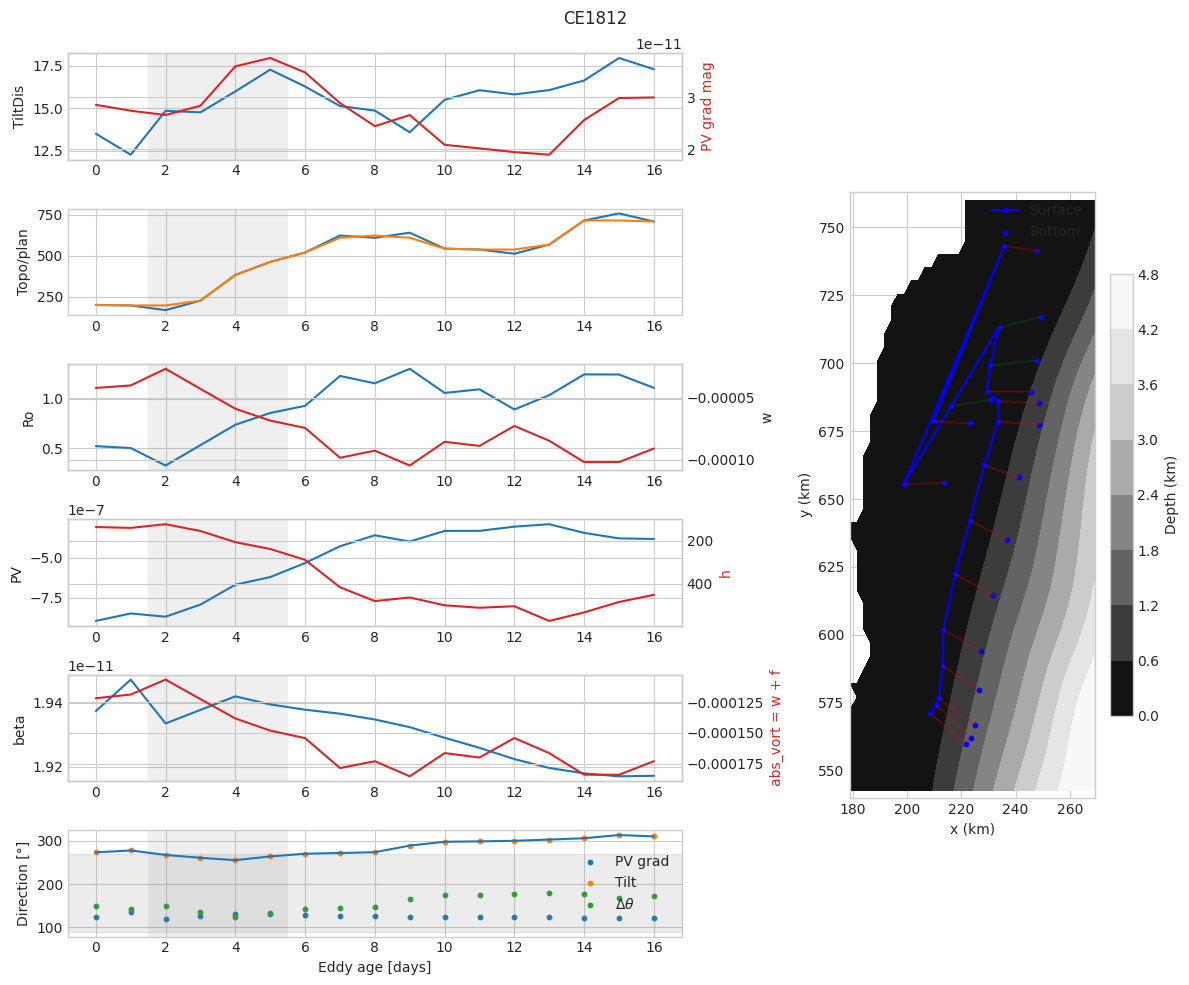

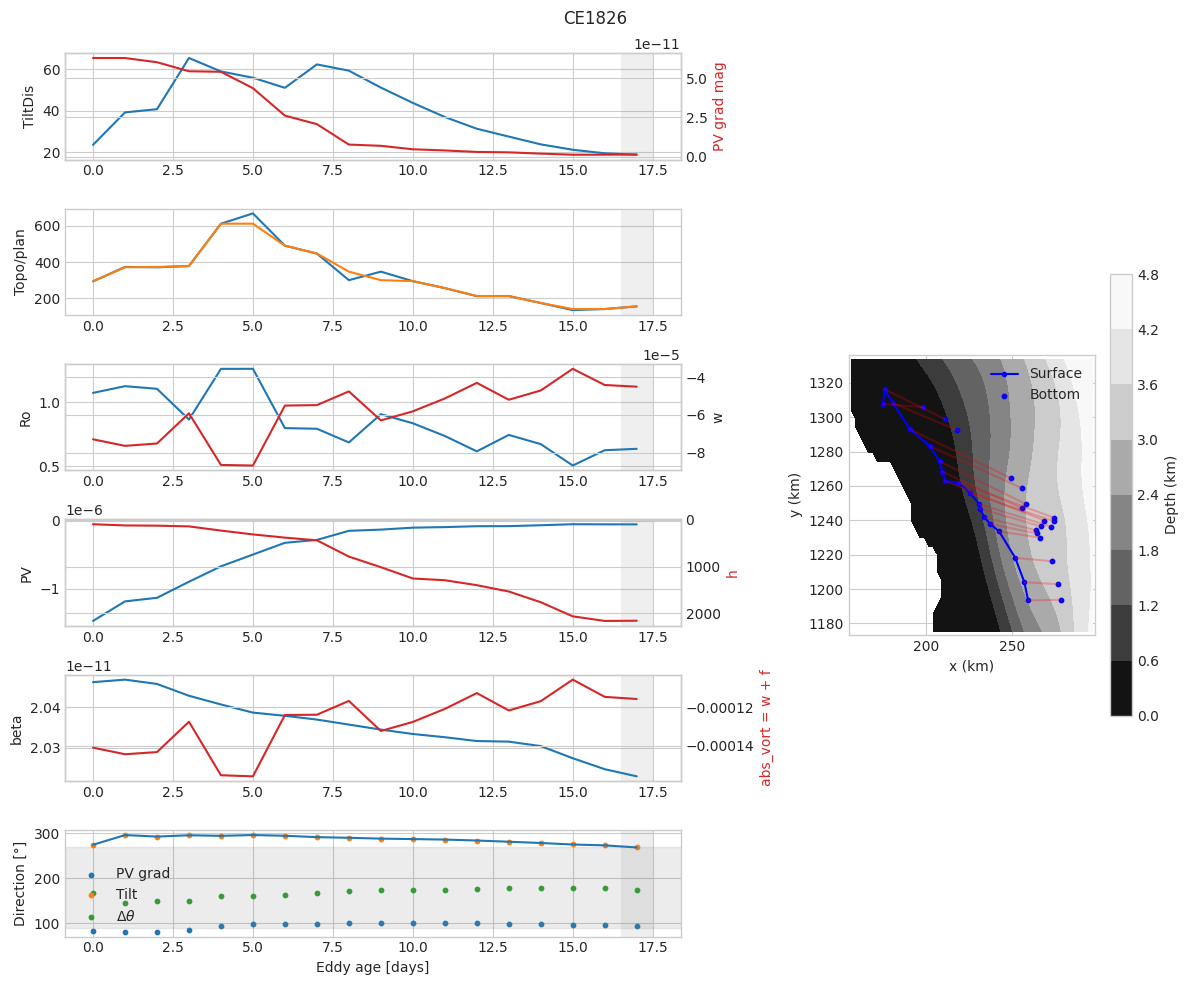

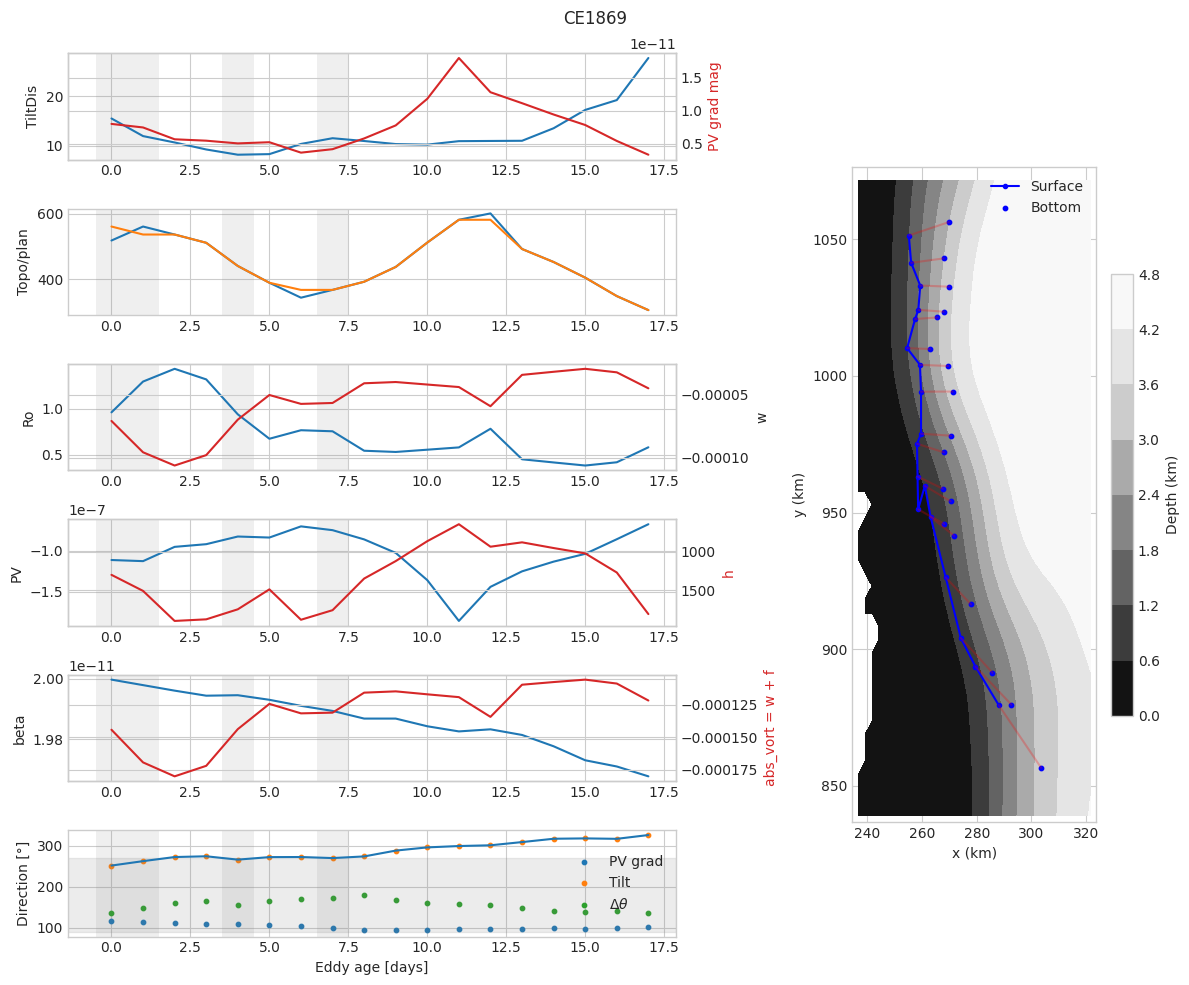

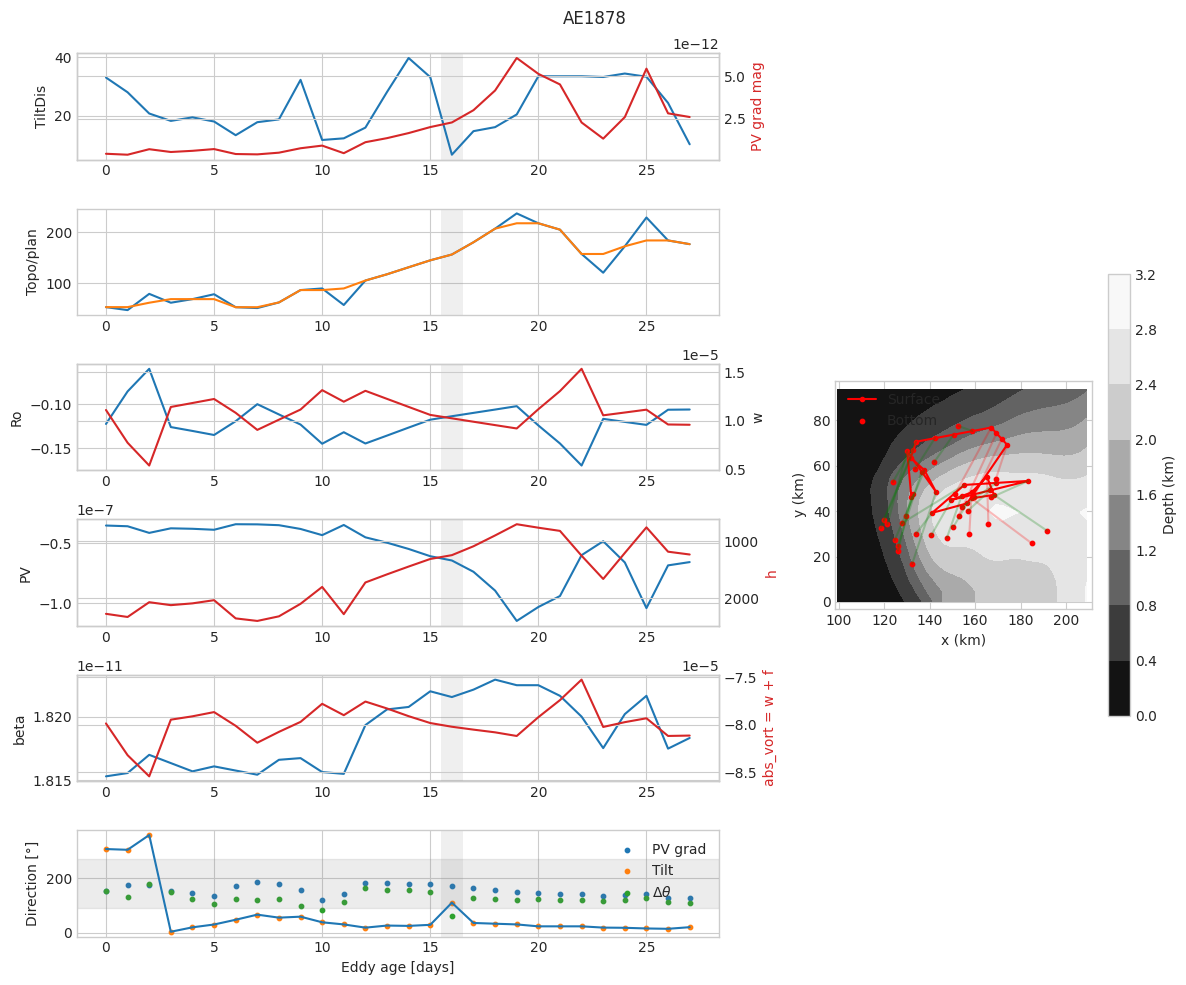

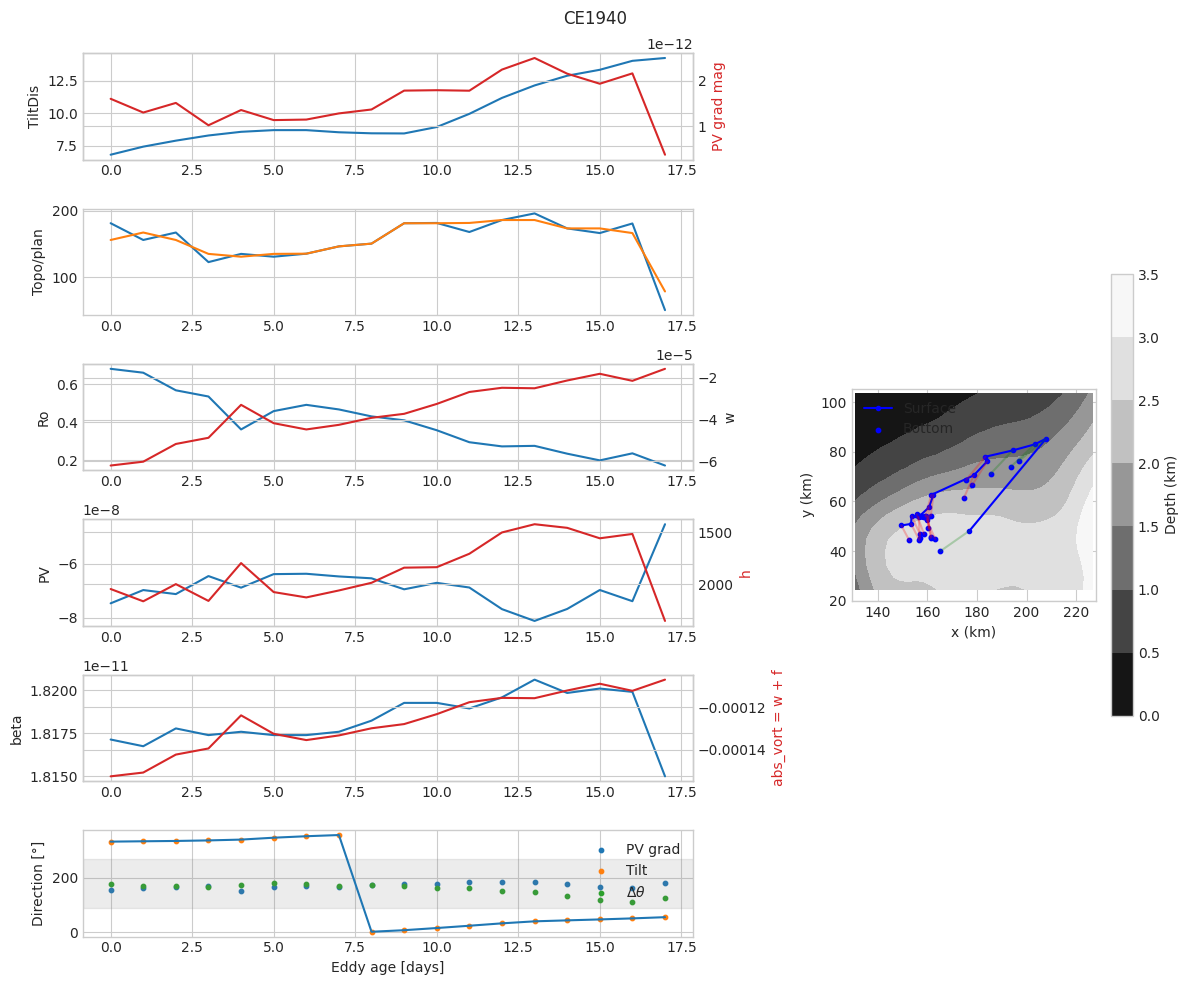

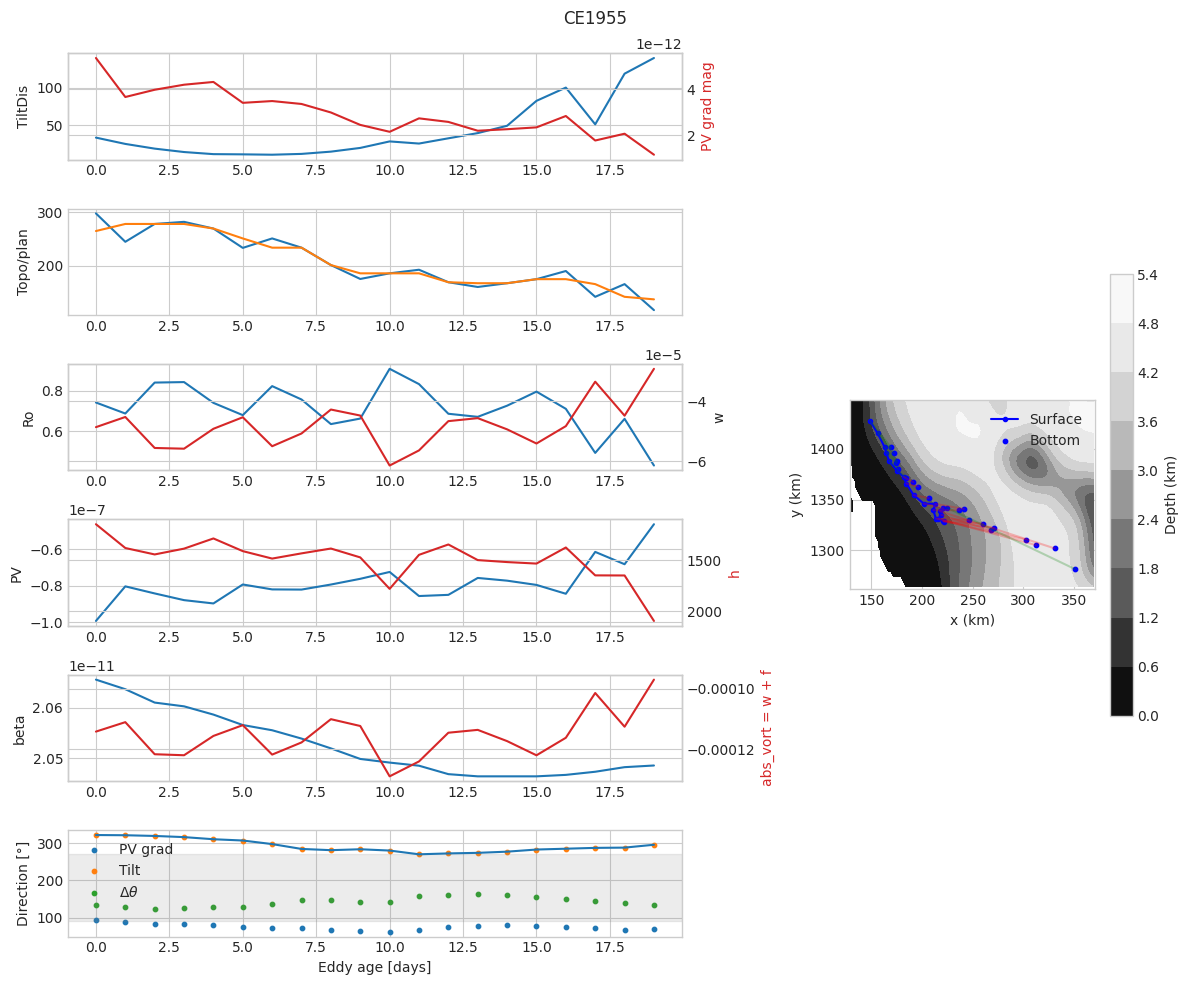

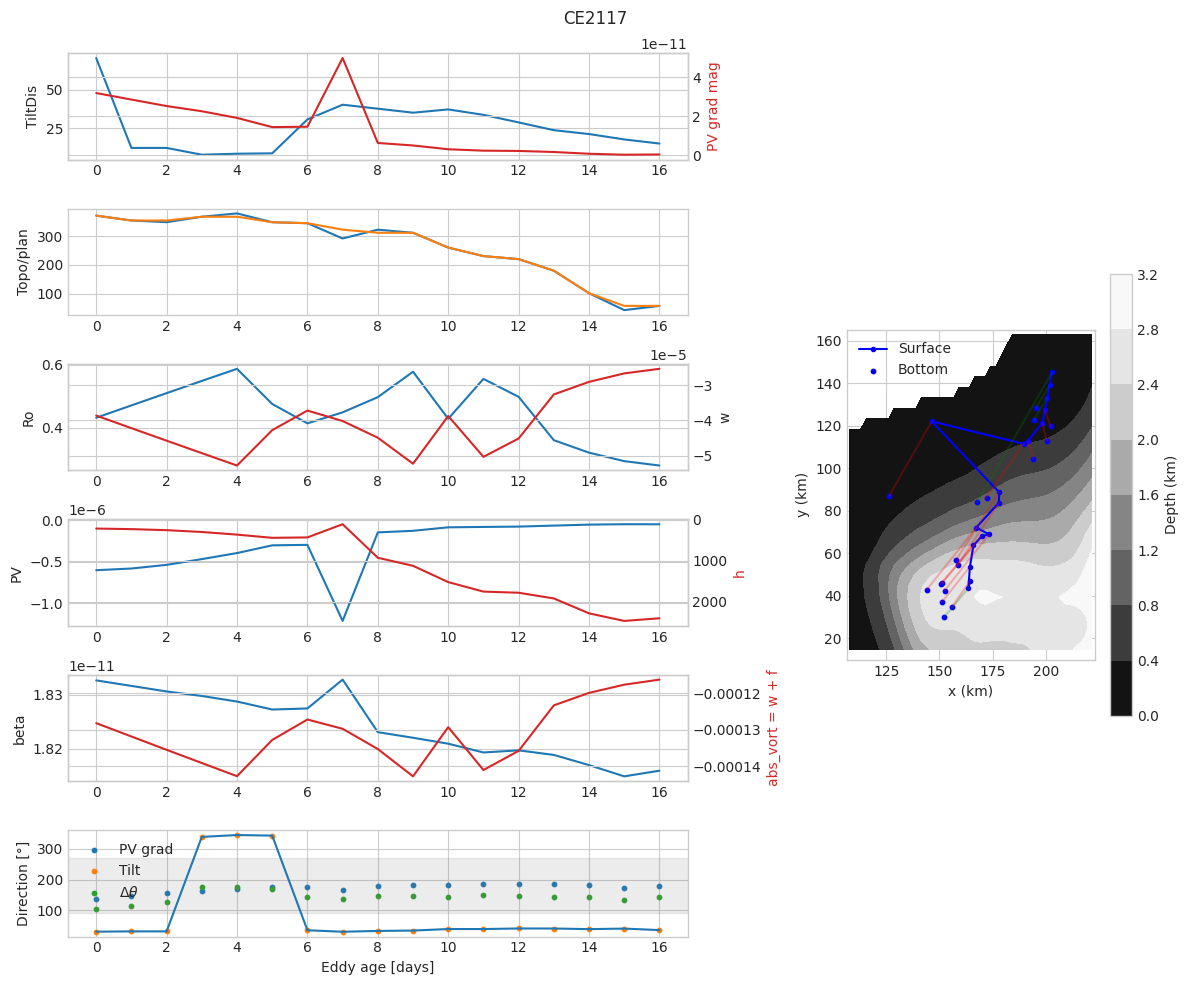

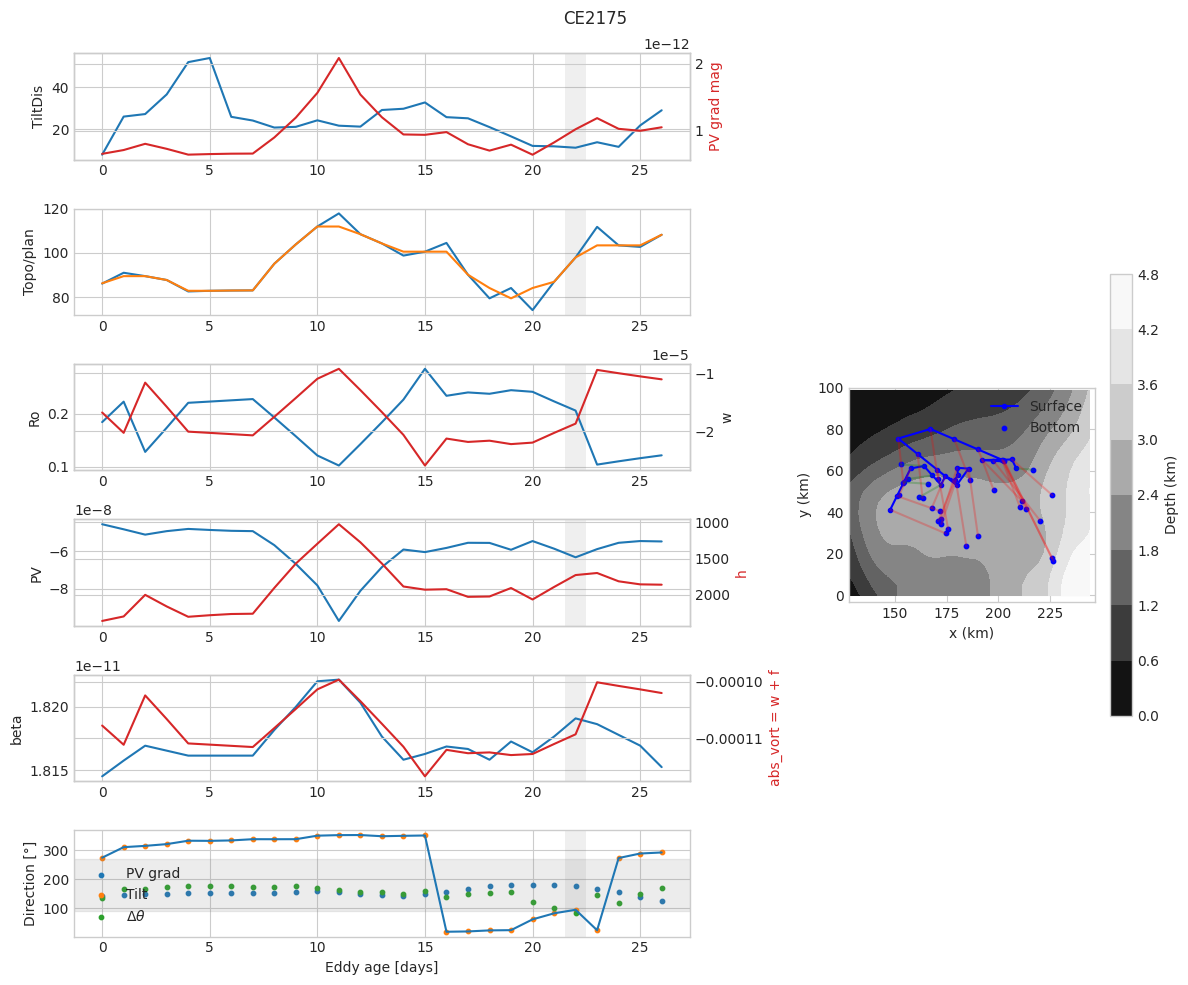

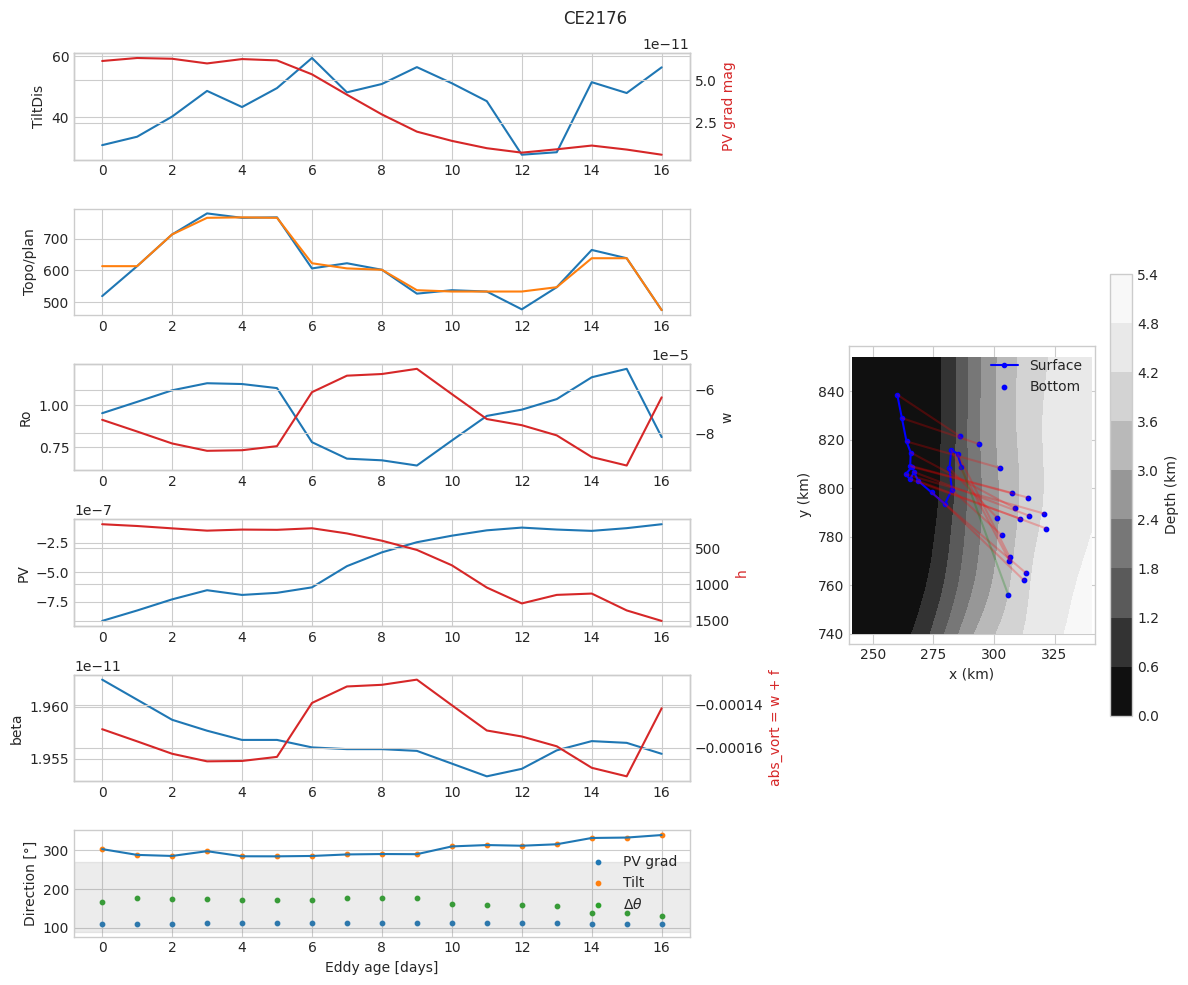

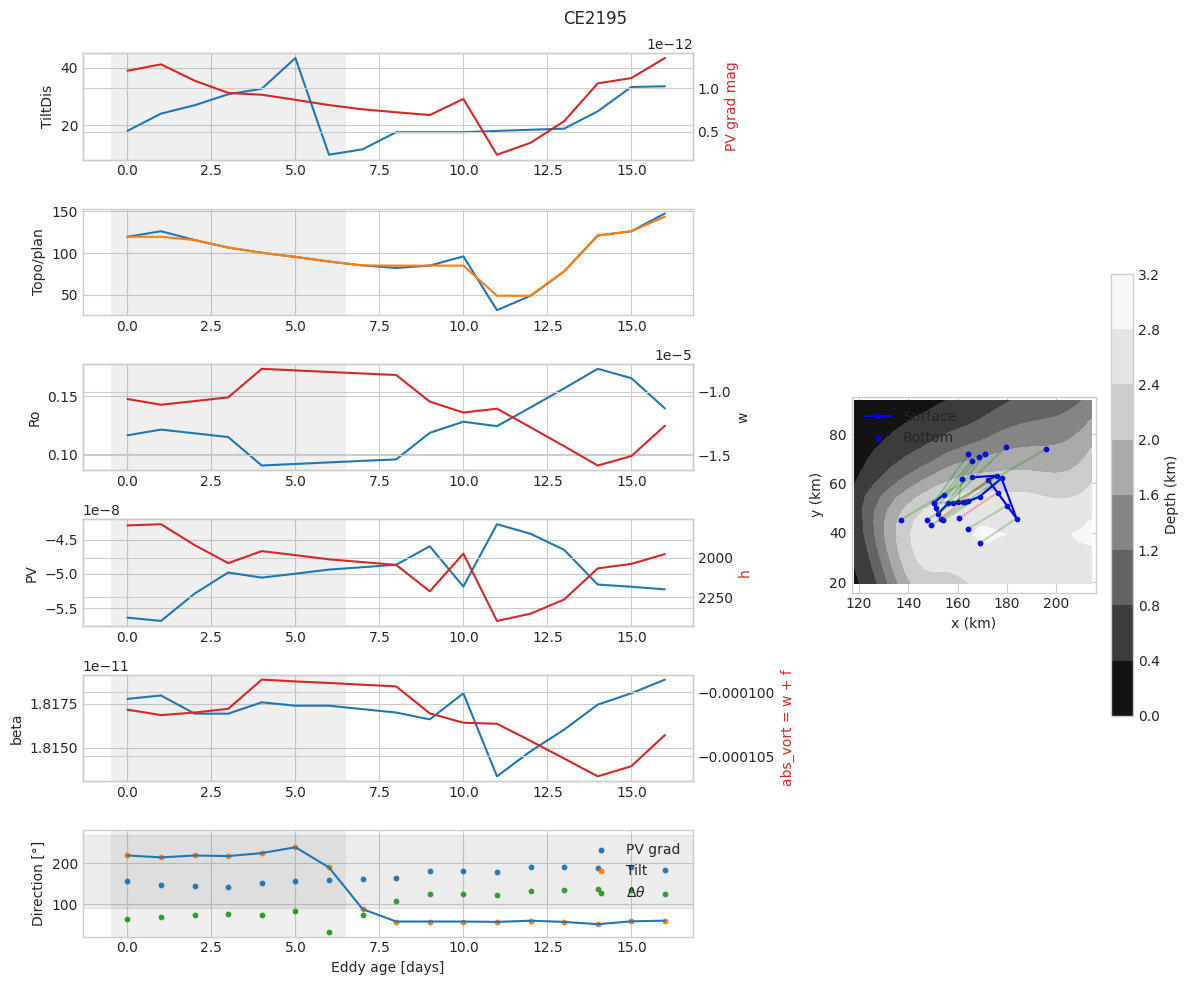

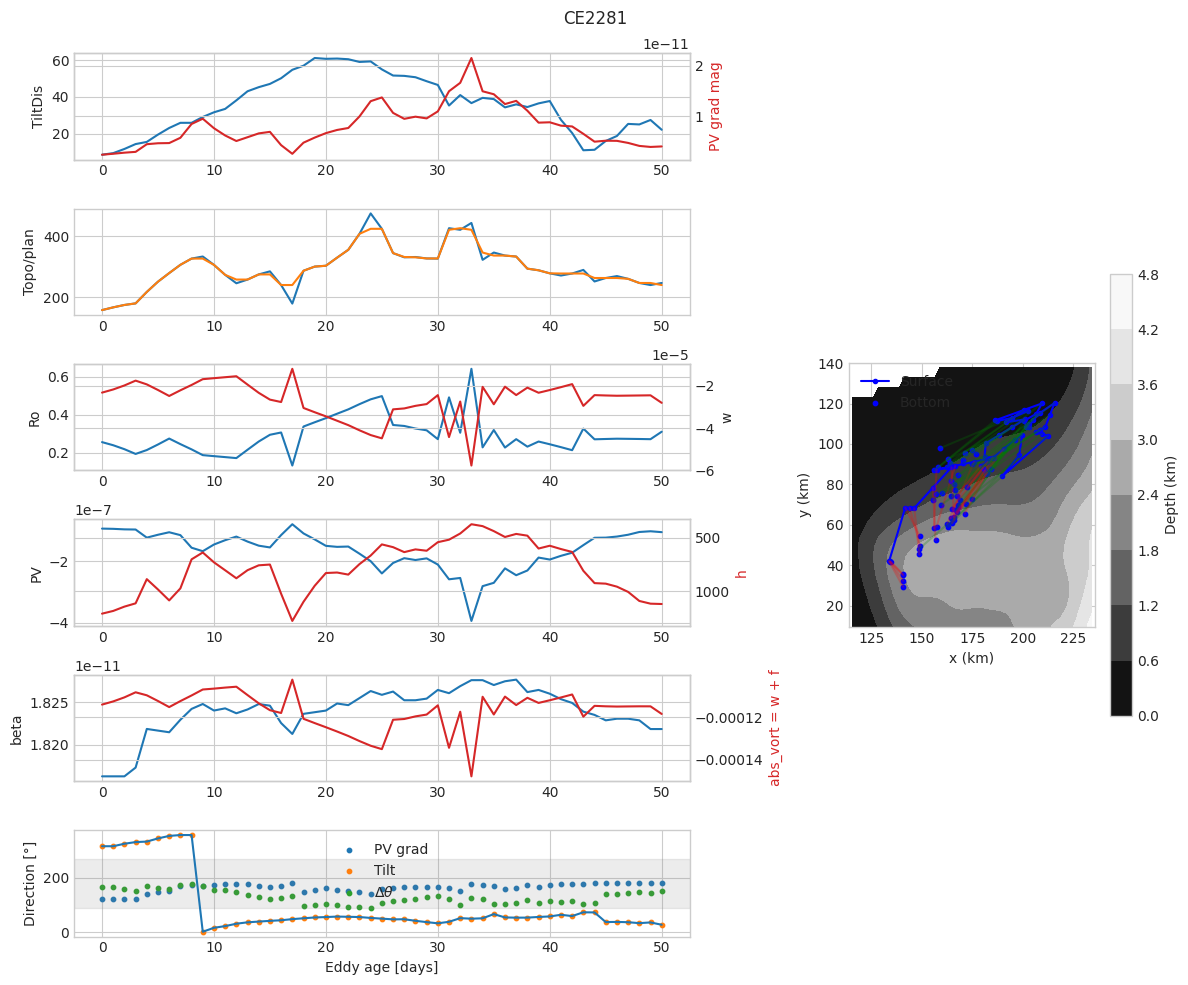

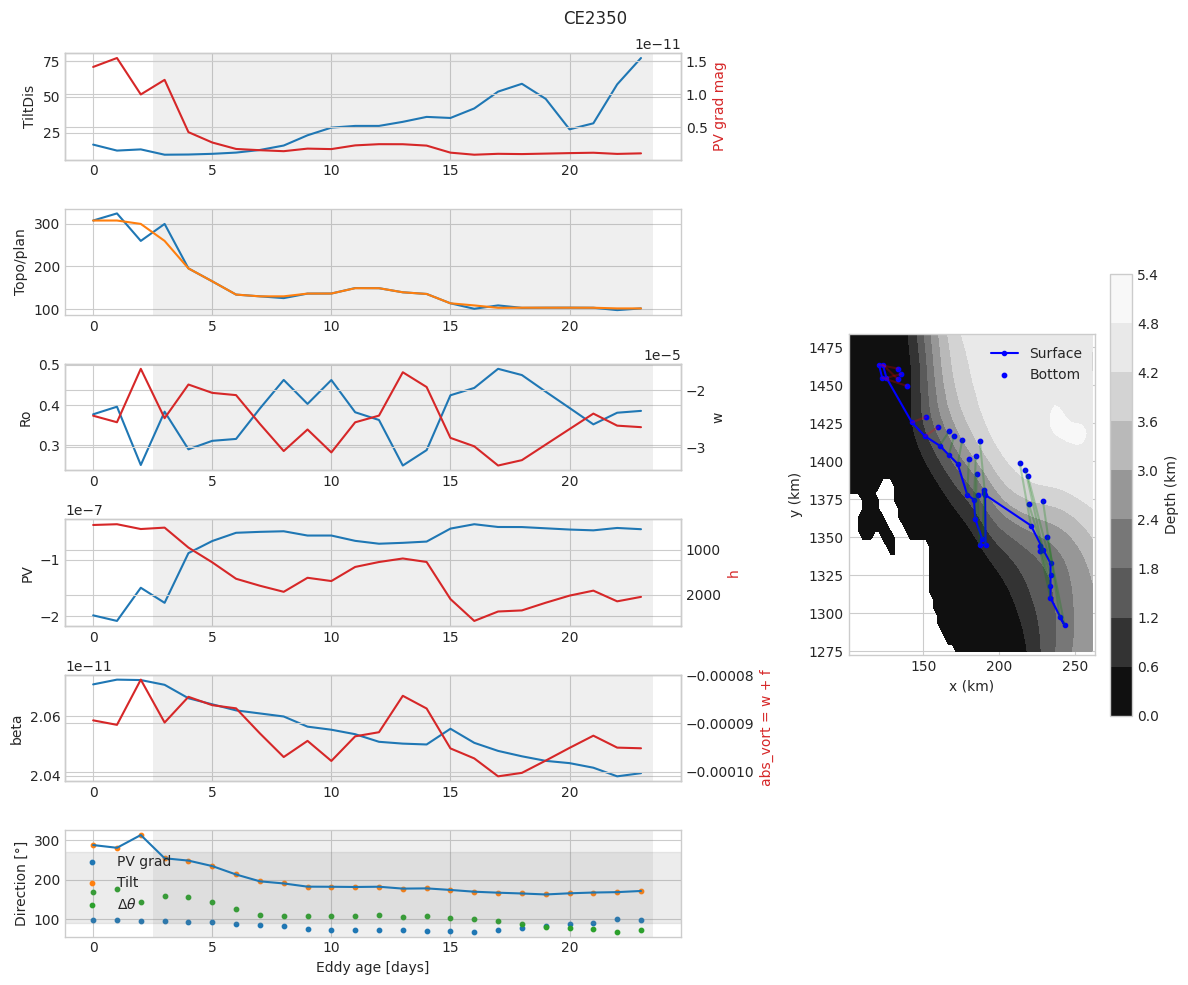

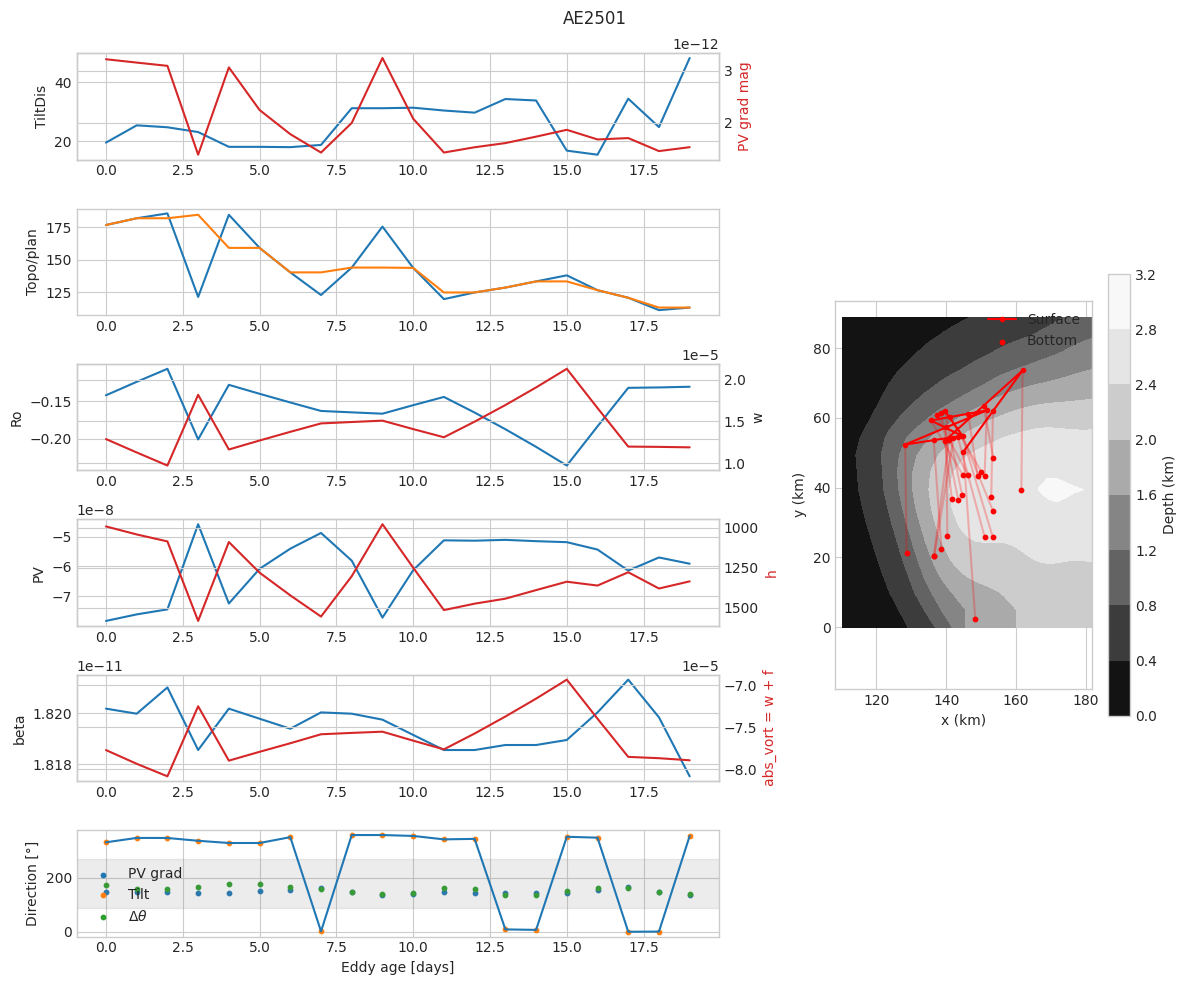

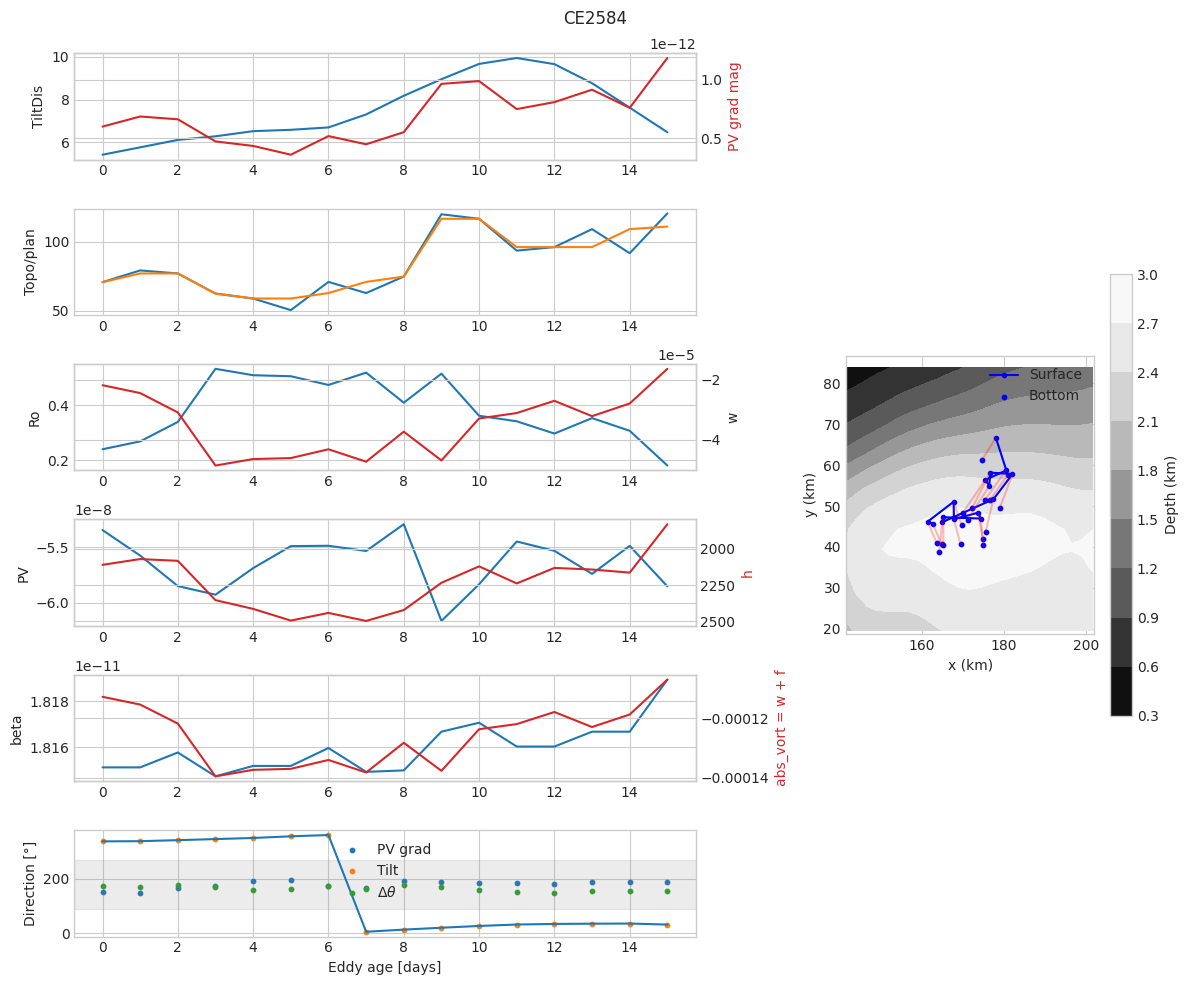

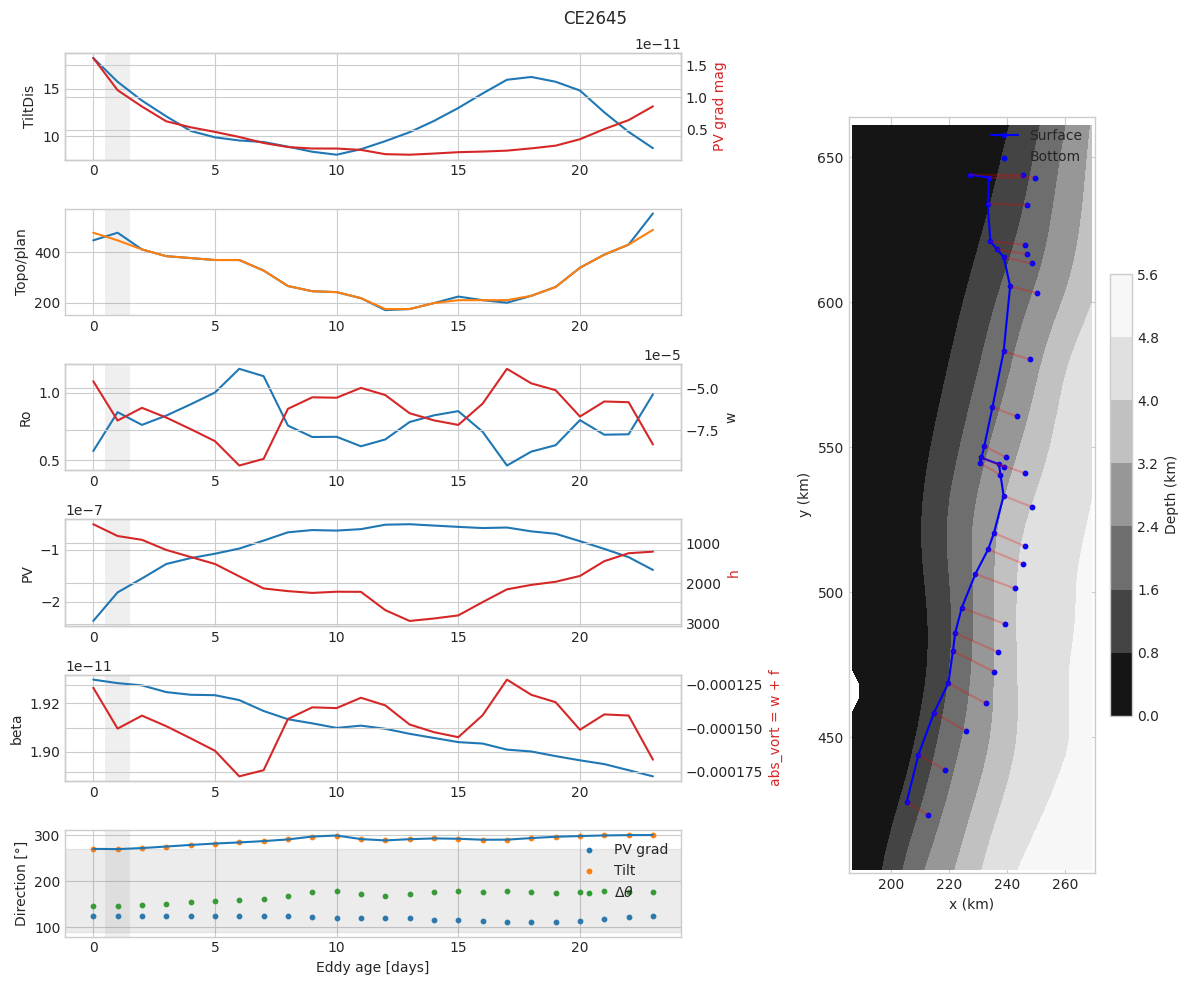

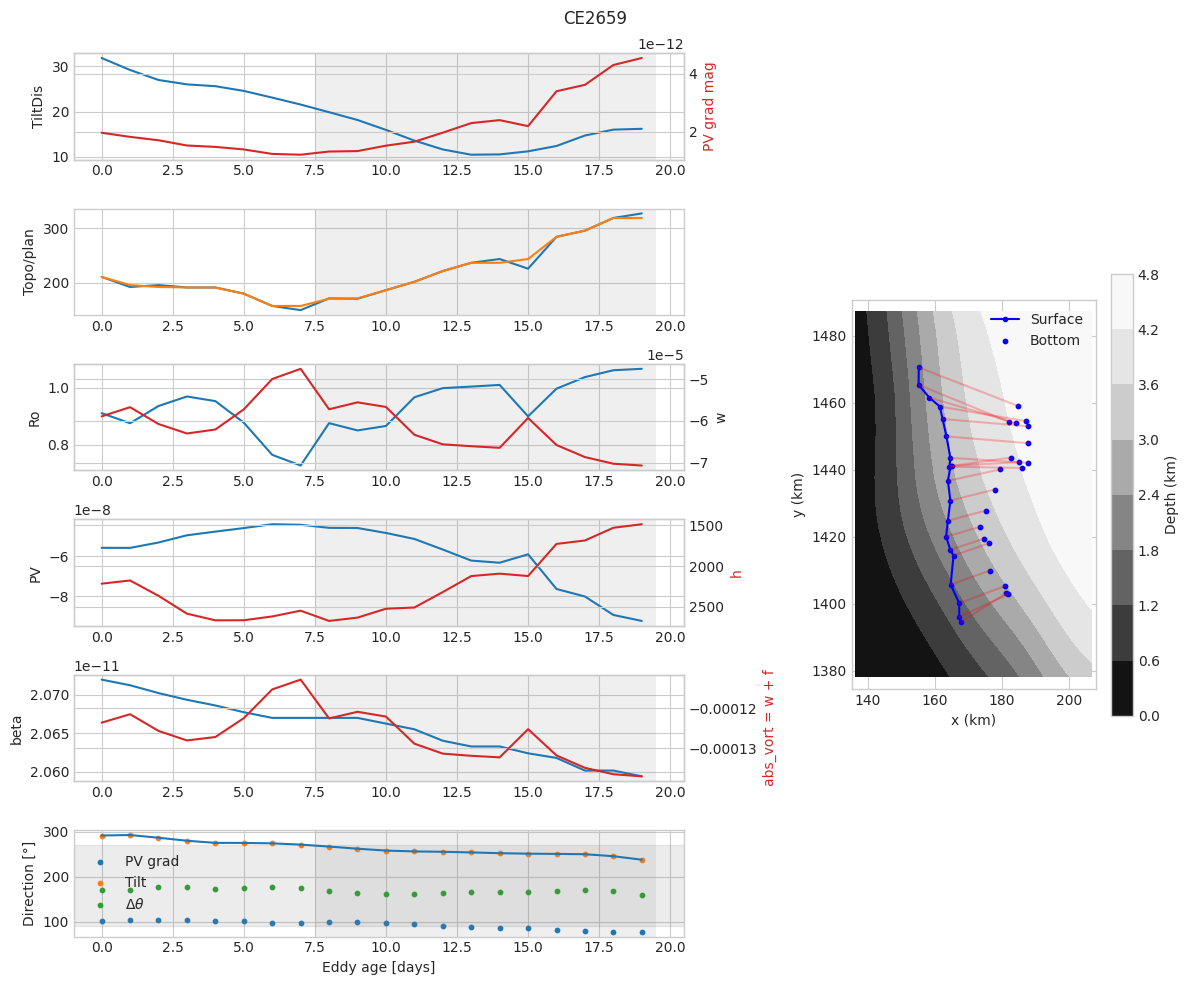

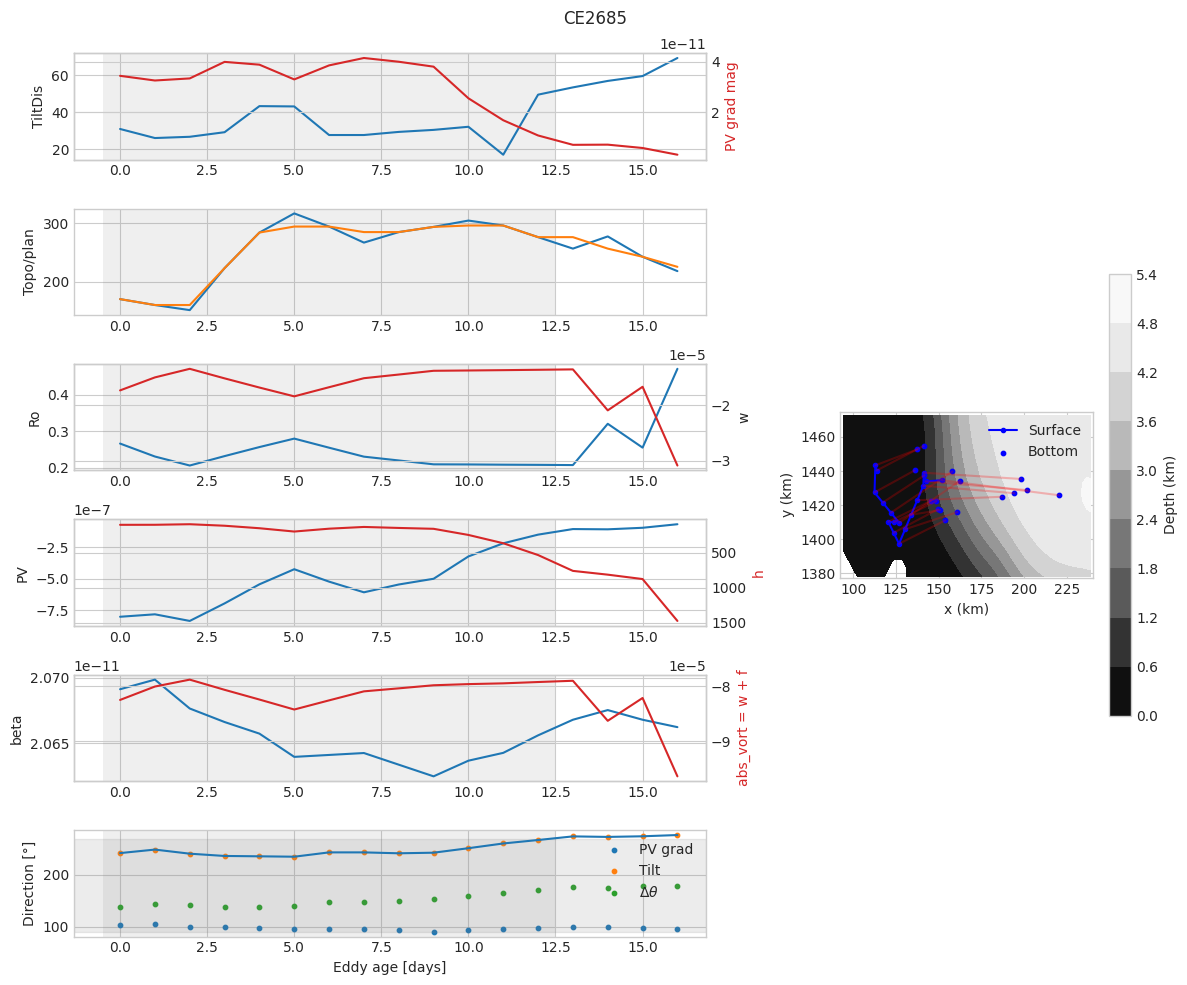

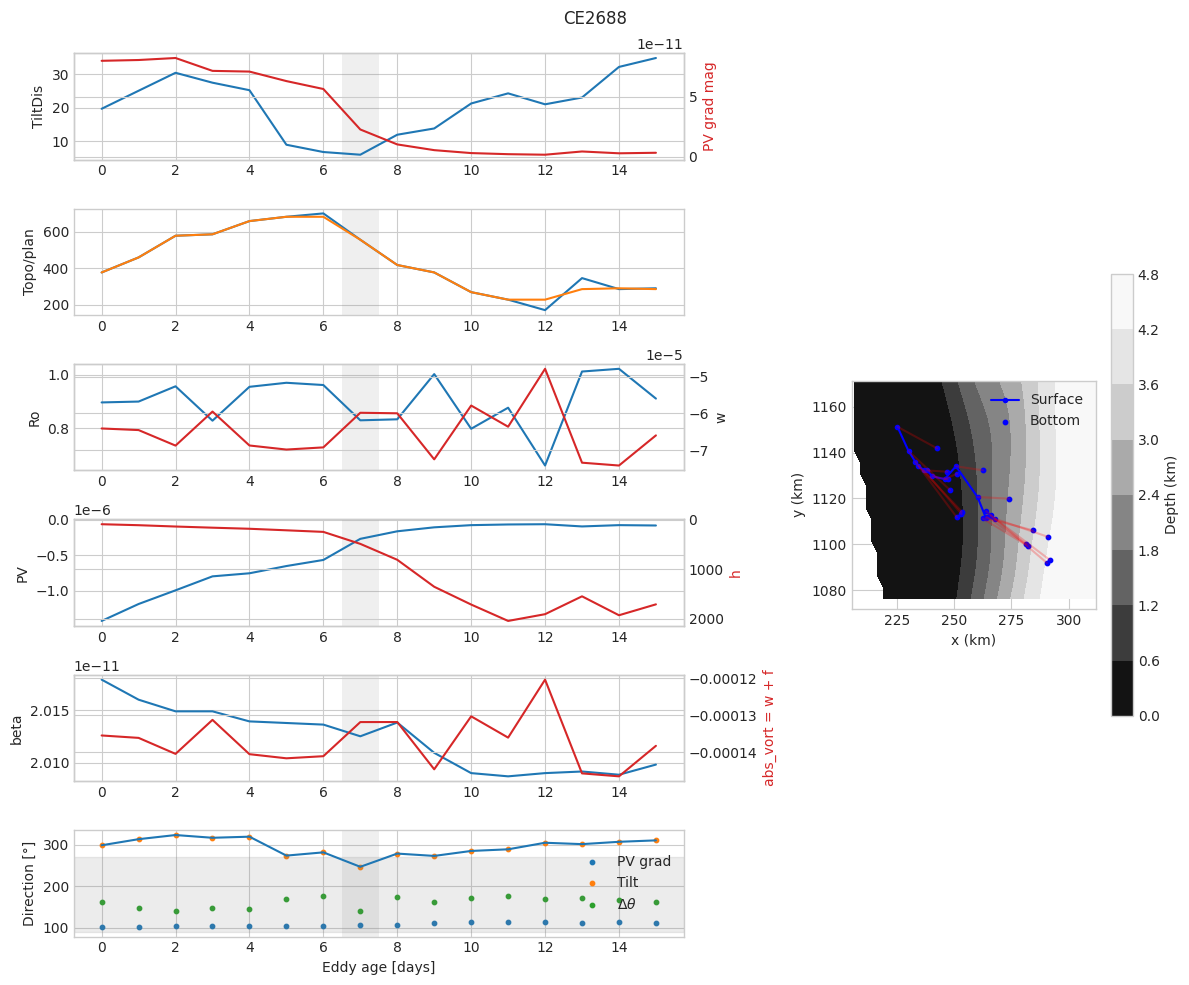

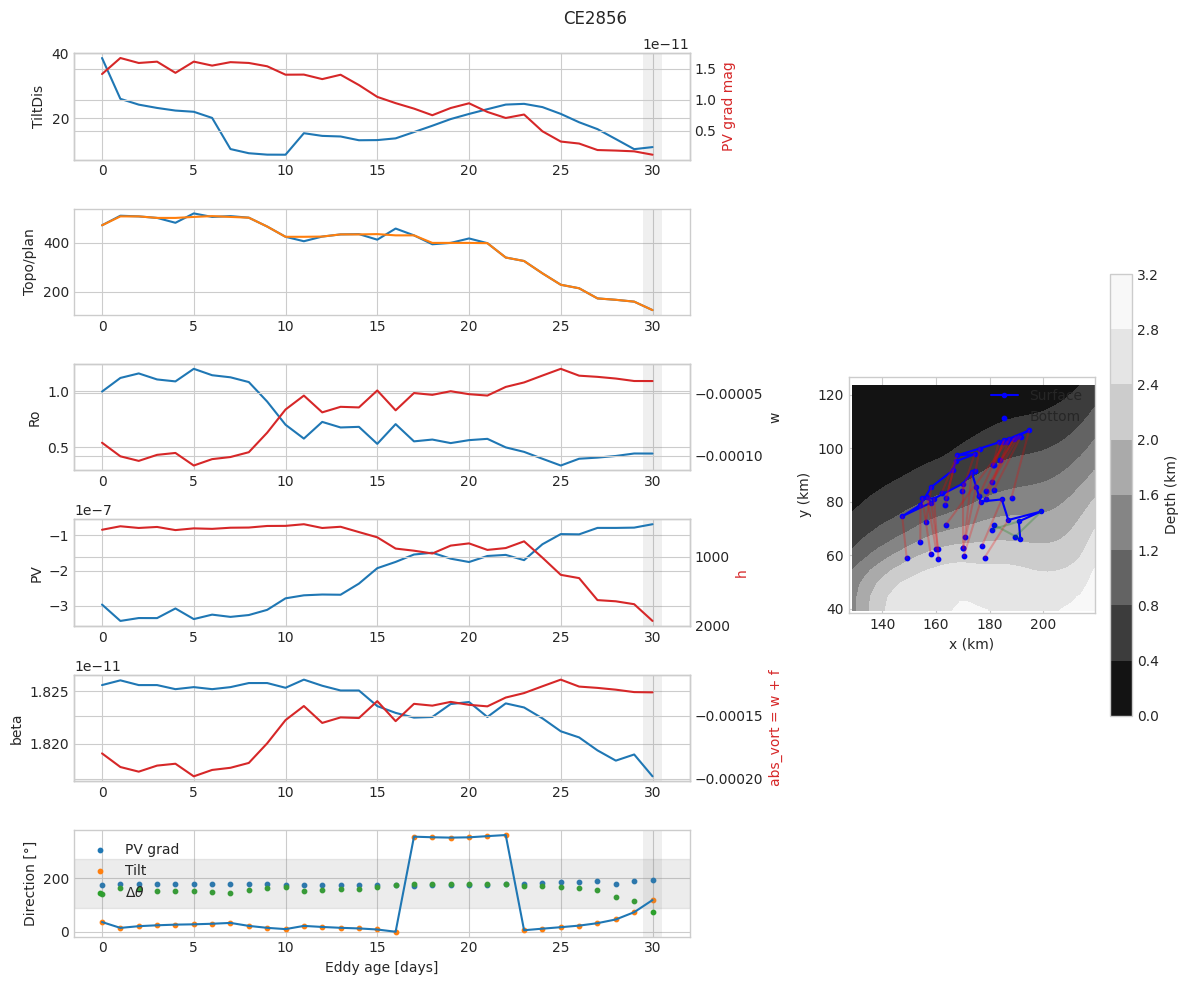

In [39]:
for eddy in df_shelf.Eddy.unique():
    time_plot(eddy, df_shelf, grid)

(np.float64(0.0),
 np.float64(988.1356688684336),
 np.float64(0.0),
 np.float64(1561.702894718129))

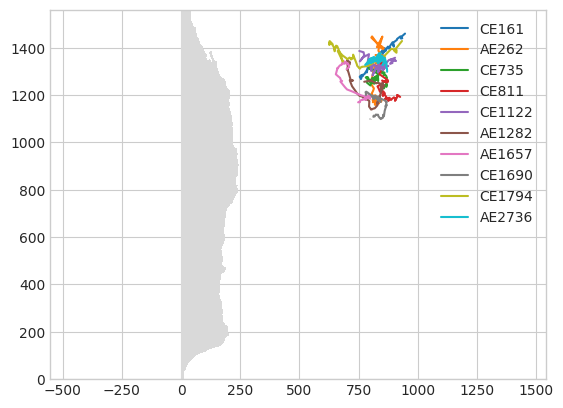

In [48]:
df_off_shelf = topographic[(topographic.Eddy.isin(complete_eddies))&(topographic.Age>55)&(topographic.shelf_class=='Off-shelf')].copy()

plt.contourf(grid.X_grid, grid.Y_grid, np.where(grid.mask_rho, np.nan,0))
for eddy in df_off_shelf.Eddy.unique():
    df = df_off_shelf[df_off_shelf.Eddy==eddy].copy()
    plt.plot(df.xc, df.yc, label=f'{df.iloc[0].Cyc}{eddy}')
plt.legend()
plt.axis('equal')

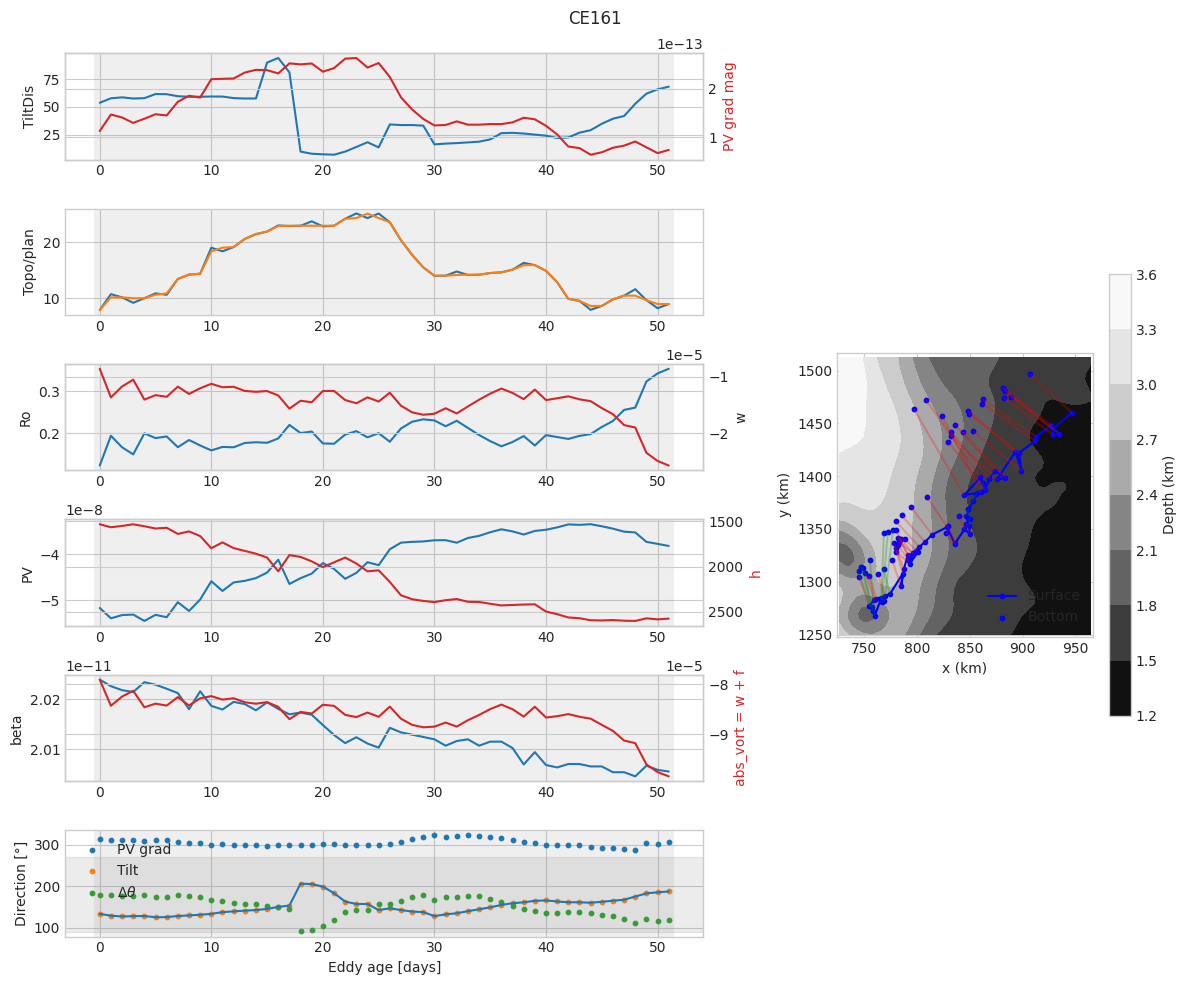

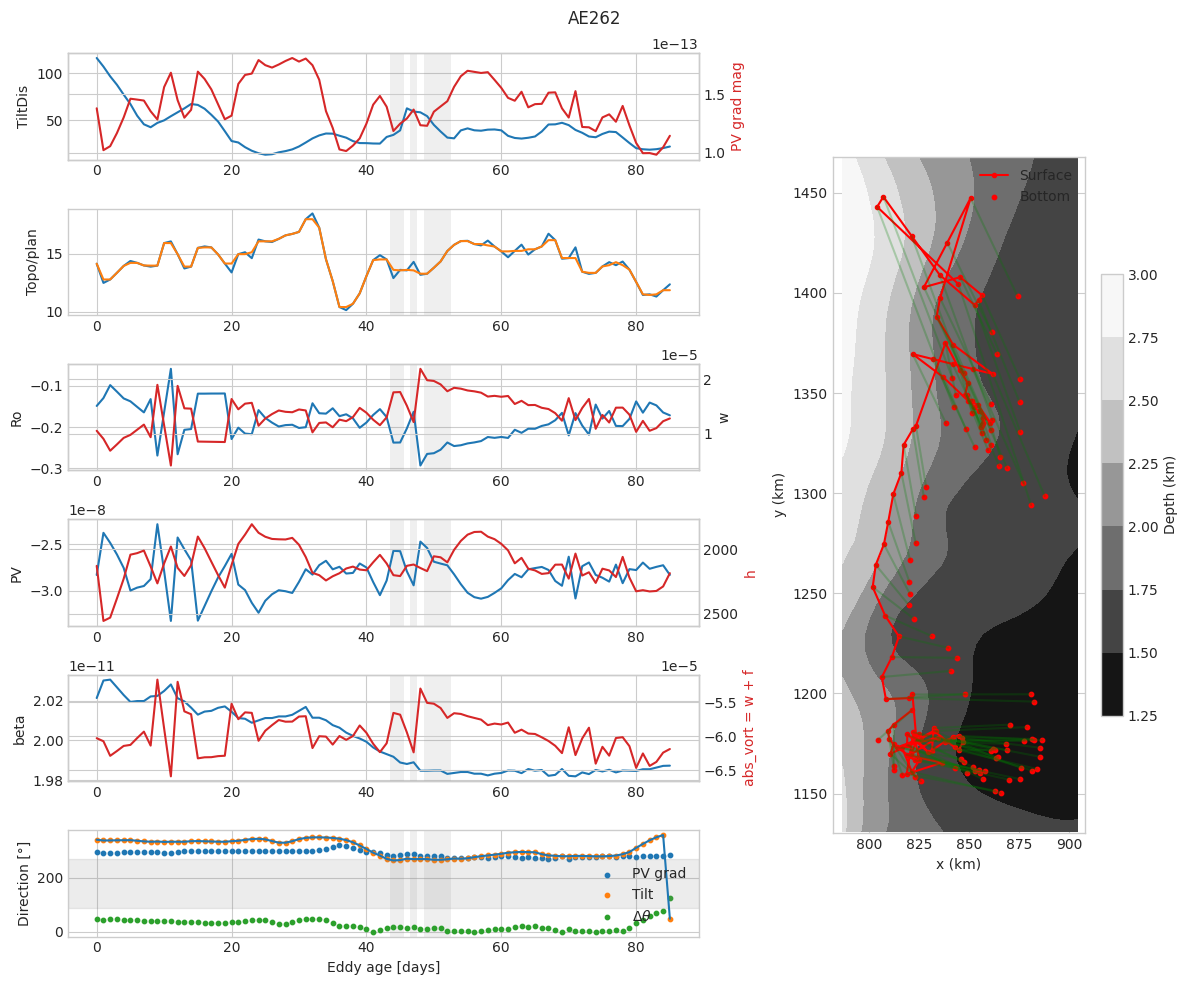

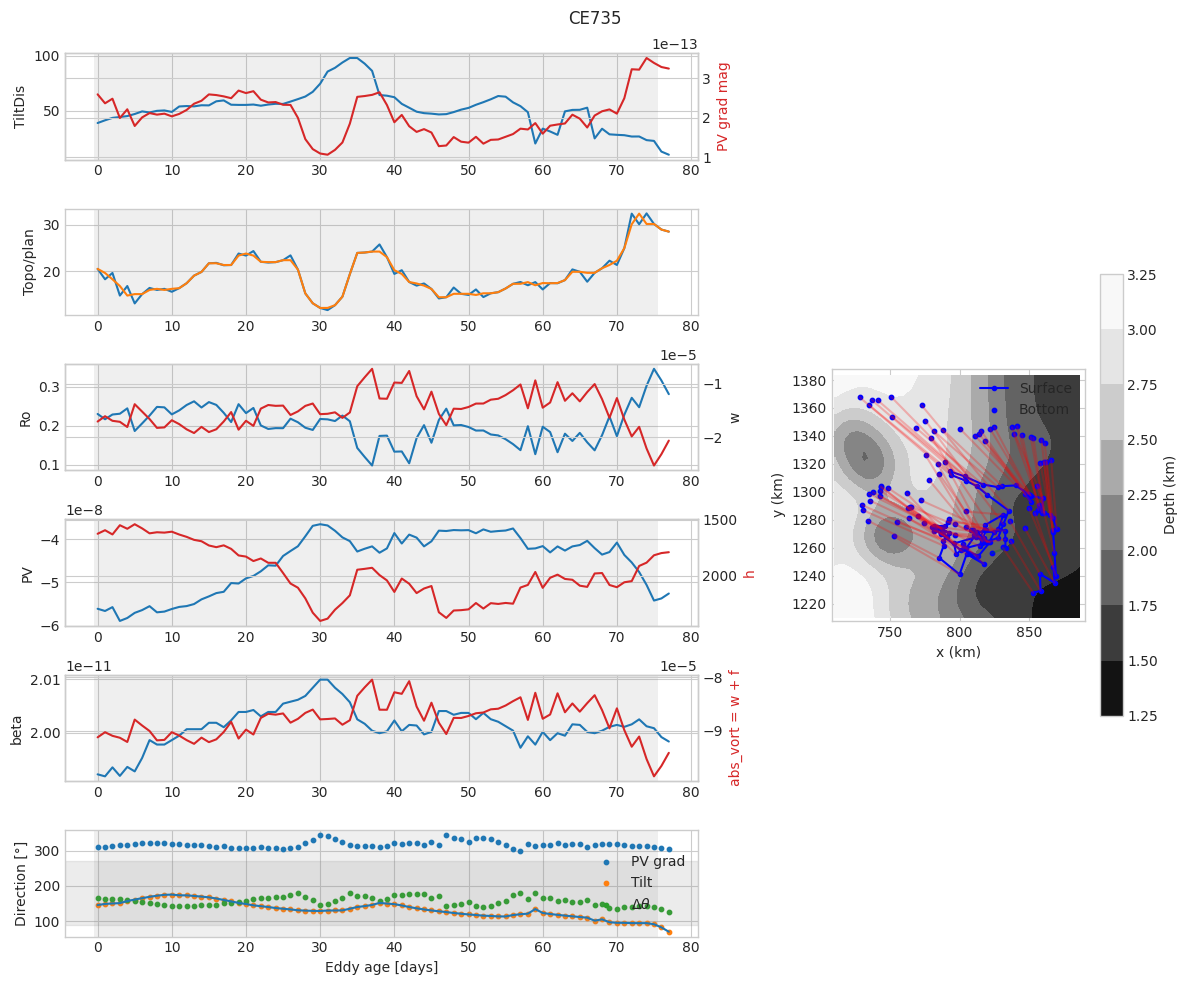

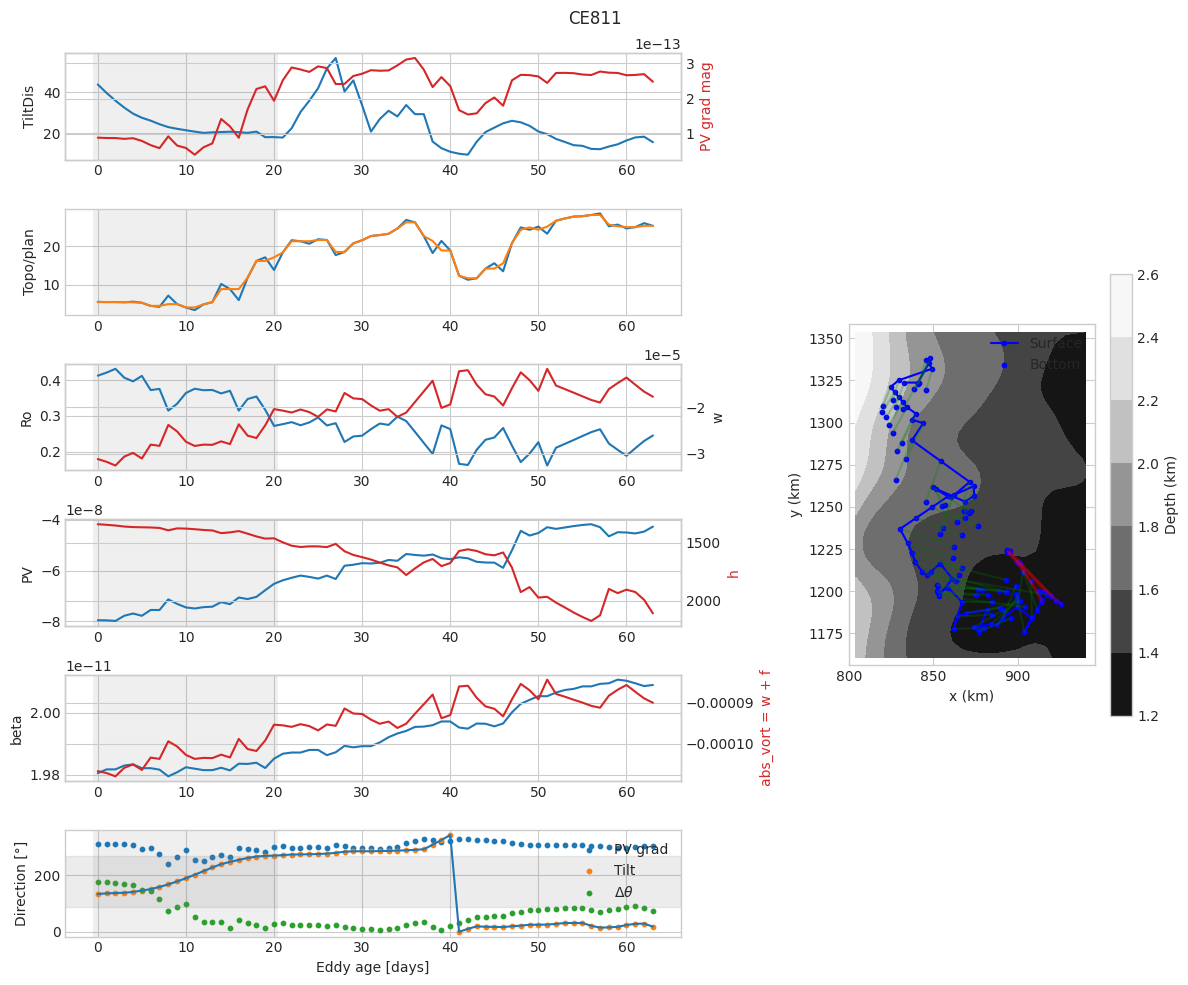

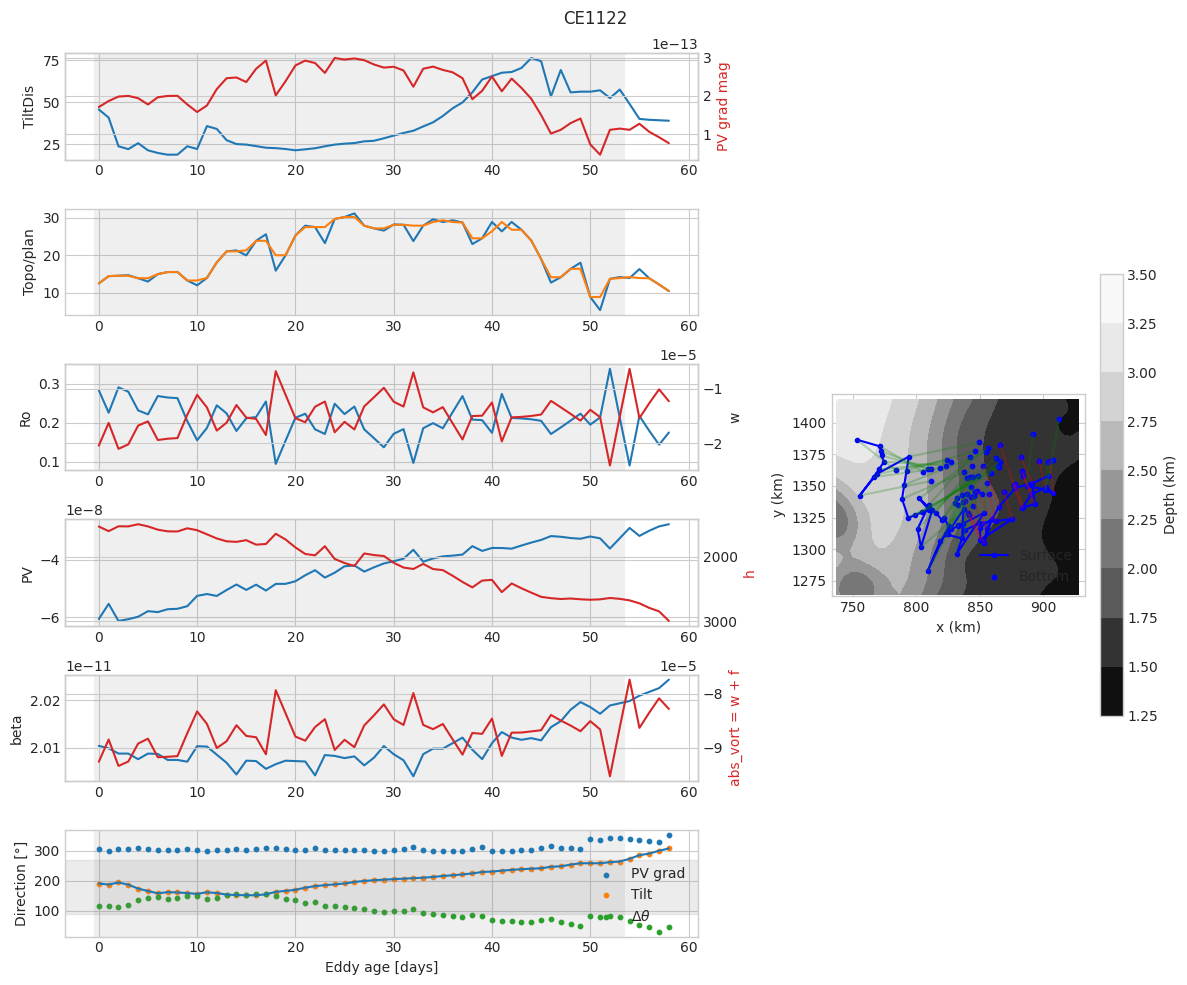

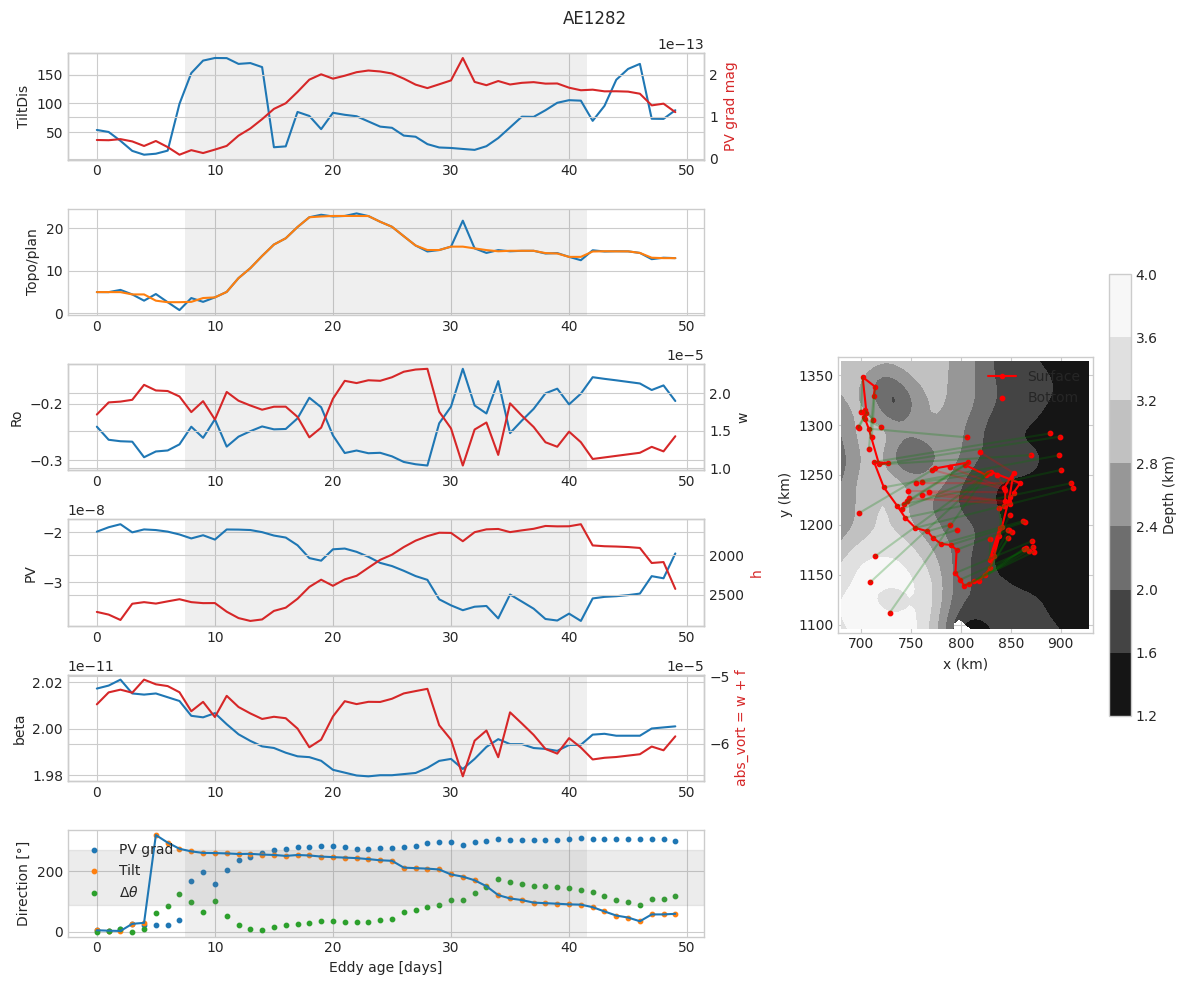

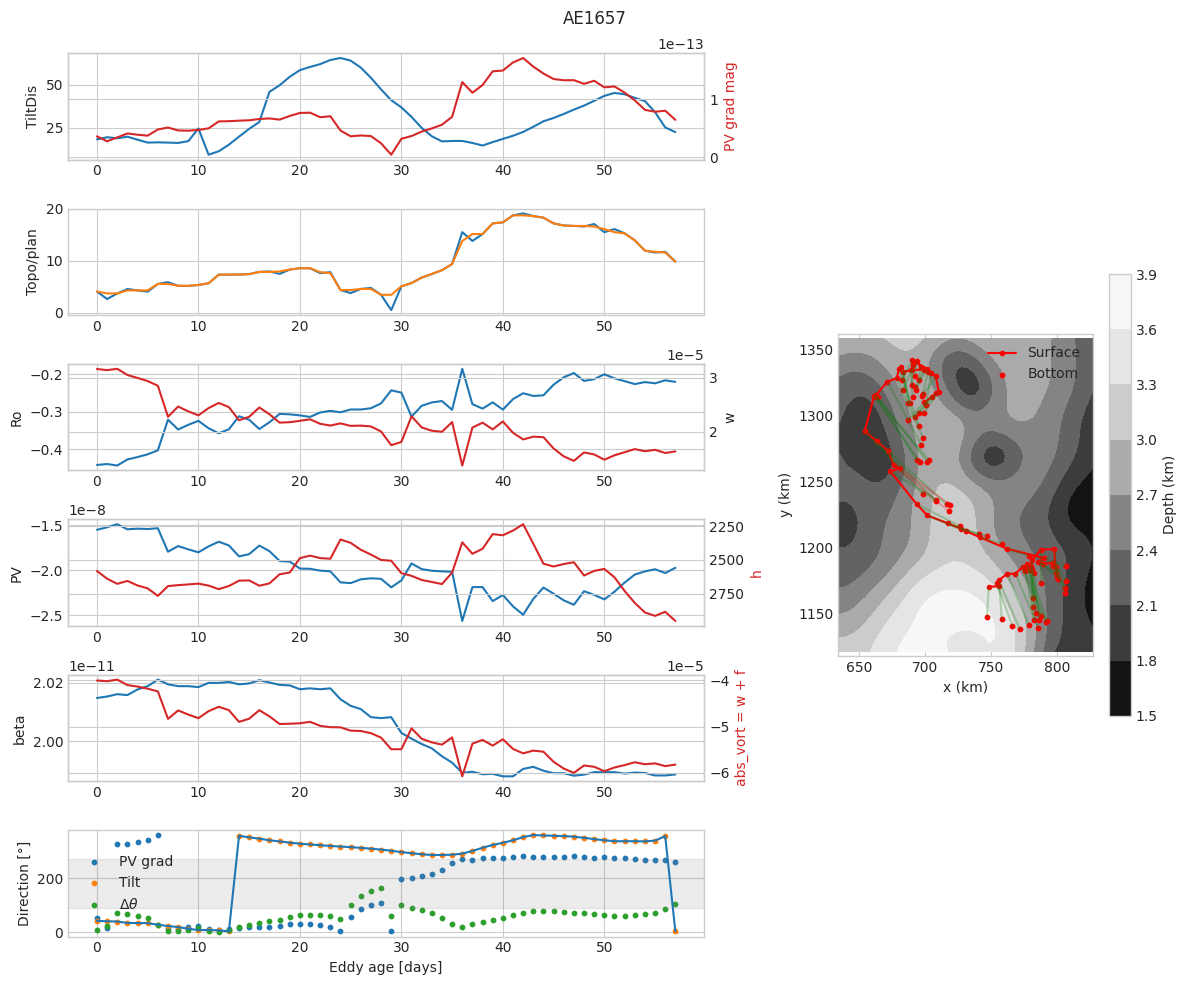

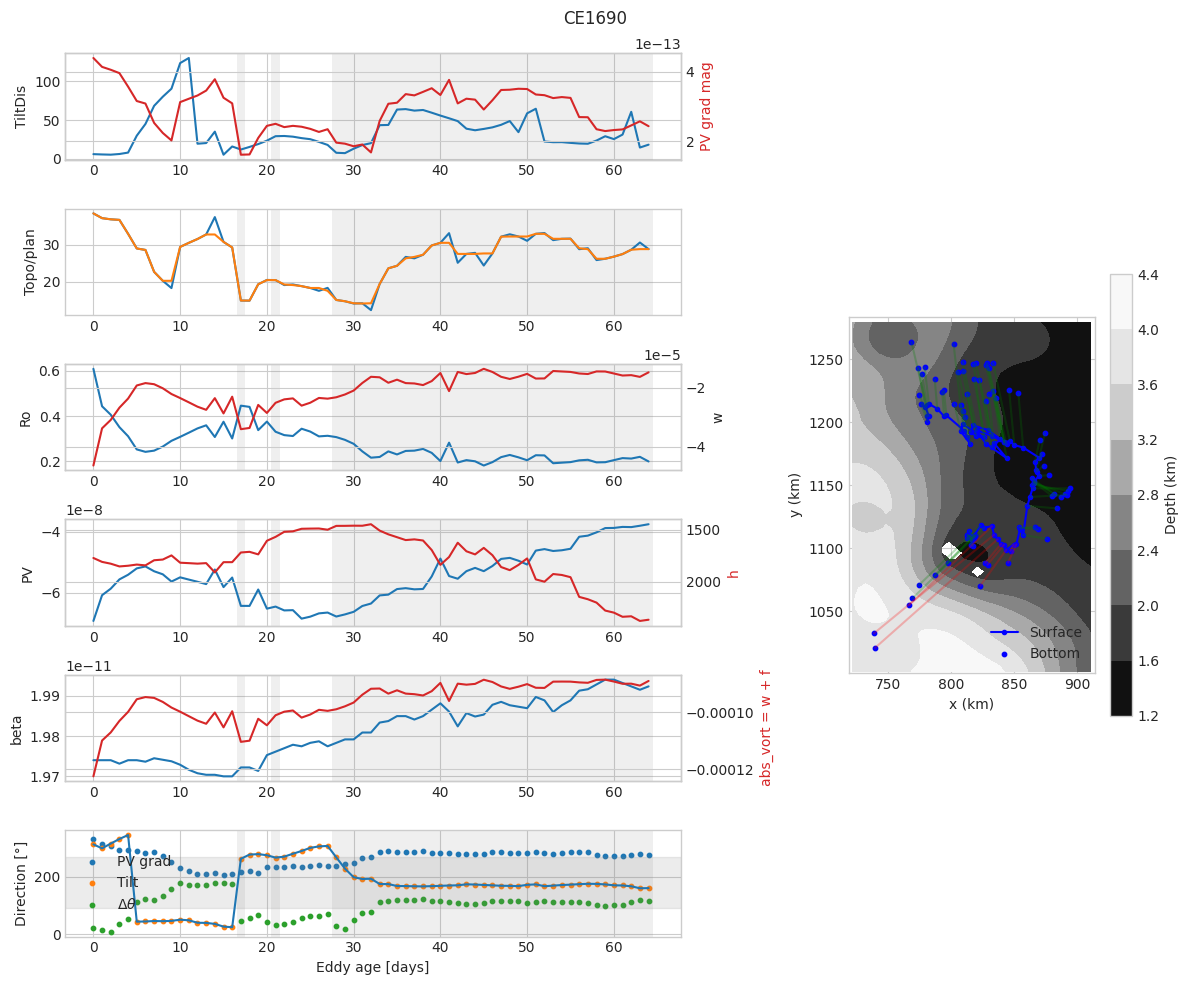

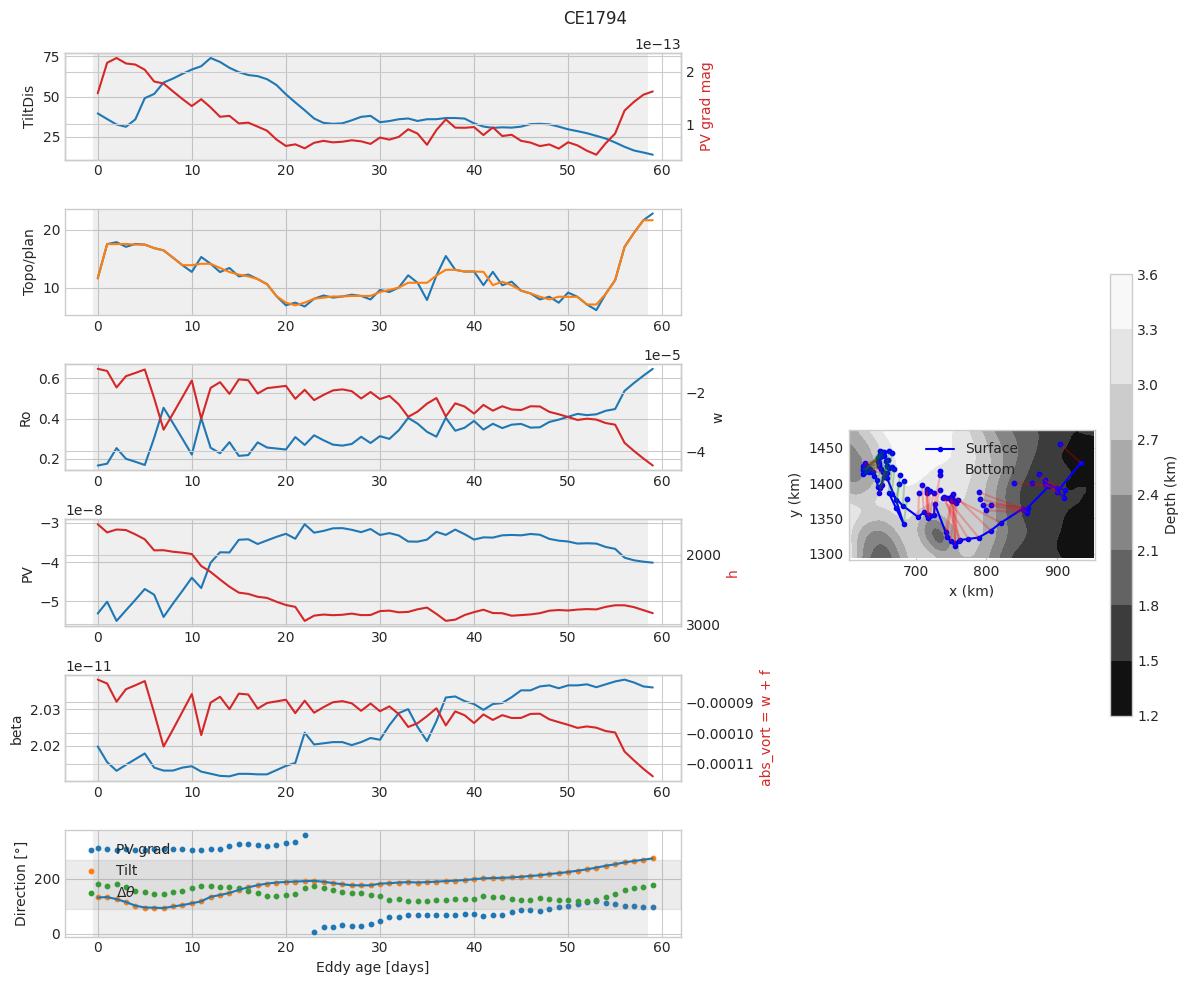

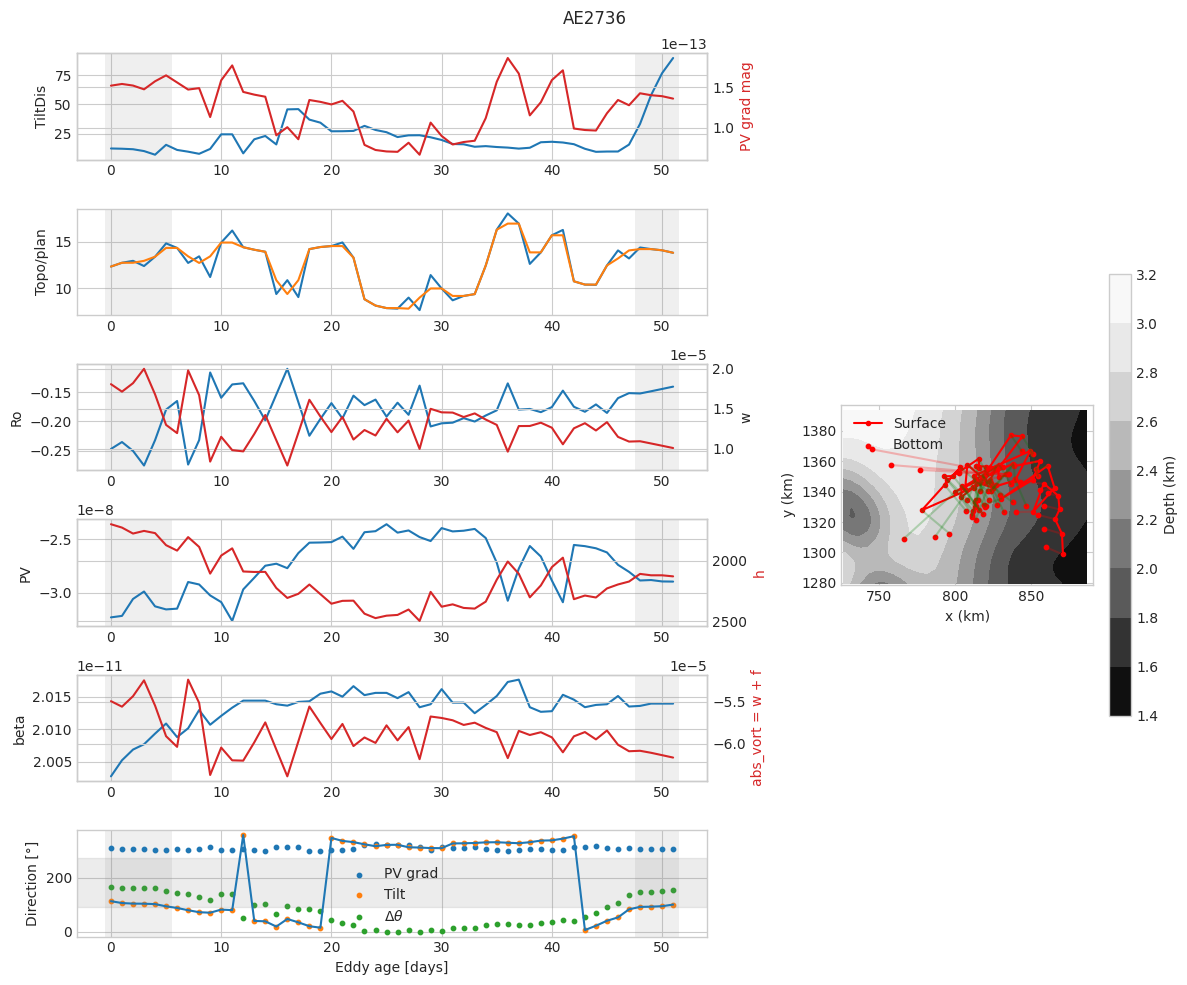

In [49]:
for eddy in df_off_shelf.Eddy.unique():
    time_plot(eddy, df_off_shelf, grid)
    